# Phân tích Cấu trúc Doanh thu và Tối ưu hoá Tồn kho
## Ứng dụng Hybrid Time-Series Model và Prescriptive Analytics

**Datathon 2026 — Round 1 | Phần 2: Khám phá Dữ liệu & Đề xuất Vận hành**

---

### Bối cảnh

Doanh nghiệp thương mại điện tử thời trang Việt Nam hoạt động 10 năm (2012-2022),
với doanh thu đạt đỉnh năm 2016 rồi suy giảm cấu trúc (structural decline).
Phân tích này kết nối **6 bảng dữ liệu** để xây dựng pipeline dự báo 18 tháng
và đề xuất các tham số vận hành tối ưu.

### Sơ đồ quan hệ từ 6 bảng dữ liệu:

```
sales.csv ←→ inventory.csv    (stockout denoising)
sales.csv ←→ promotions.csv   (intervention analysis)
sales.csv ←→ web_traffic.csv  (leading indicator)
products  →  order_items → orders  (category analysis)
Revenue   ←→ COGS             (cointegration & margin)
```

In [17]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup paths
ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

CSV_DIR = os.path.join(ROOT, "csv")
OUT_DIR = os.path.join(ROOT, "outputs", "part2")
os.makedirs(OUT_DIR, exist_ok=True)

# Load core data
sales = pd.read_csv(os.path.join(CSV_DIR, "sales.csv"), parse_dates=["Date"]).set_index("Date")
print(f"Sales data: {sales.index.min().date()} -> {sales.index.max().date()} ({len(sales)} rows)")
print(f"Revenue: mean={sales['Revenue'].mean()/1e6:.2f}M, std={sales['Revenue'].std()/1e6:.2f}M")
print(f"COGS:    mean={sales['COGS'].mean()/1e6:.2f}M, std={sales['COGS'].std()/1e6:.2f}M")
print(f"Corr(Revenue, COGS) = {sales[['Revenue','COGS']].corr().iloc[0,1]:.4f}")

Sales data: 2012-07-04 -> 2022-12-31 (3833 rows)
Revenue: mean=4.29M, std=2.62M
COGS:    mean=3.70M, std=2.22M
Corr(Revenue, COGS) = 0.9760


---
# 1. Phân tích Mô tả (Descriptive Analytics)

Mục tiêu: Đánh giá phân phối và xu hướng cấu trúc của doanh thu, chi phí trong giai đoạn 2012-2022.

## Viz 1: Doanh thu đạt đỉnh 2016 rồi suy giảm cấu trúc -44%

Biểu đồ cho thấy **xu hướng dài hạn đi xuống** — hồi quy tuyến tính có slope **-41M/năm**.

**Hai giai đoạn rõ rệt:**
- **2012 → 2016:** Tăng trưởng mạnh từ 741M → 2,105M (đỉnh)
- **2016 → 2022:** Suy giảm cấu trúc -44%, ổn định quanh mức 1,050-1,170M

**Key finding:** Doanh thu 2022 (1,170M) vẫn thấp hơn đỉnh 2016 đến 44%.
So với 2013 (1,657M), doanh thu 2022 giảm **-29.4%** — đây là structural decline,
không phải tăng trưởng.

**So what?** Mô hình dự báo cần nhận diện được điểm gãy cấu trúc (structural break)
năm 2019 để tránh bị nhiễu bởi dữ liệu giai đoạn tăng trưởng 2012-2016.

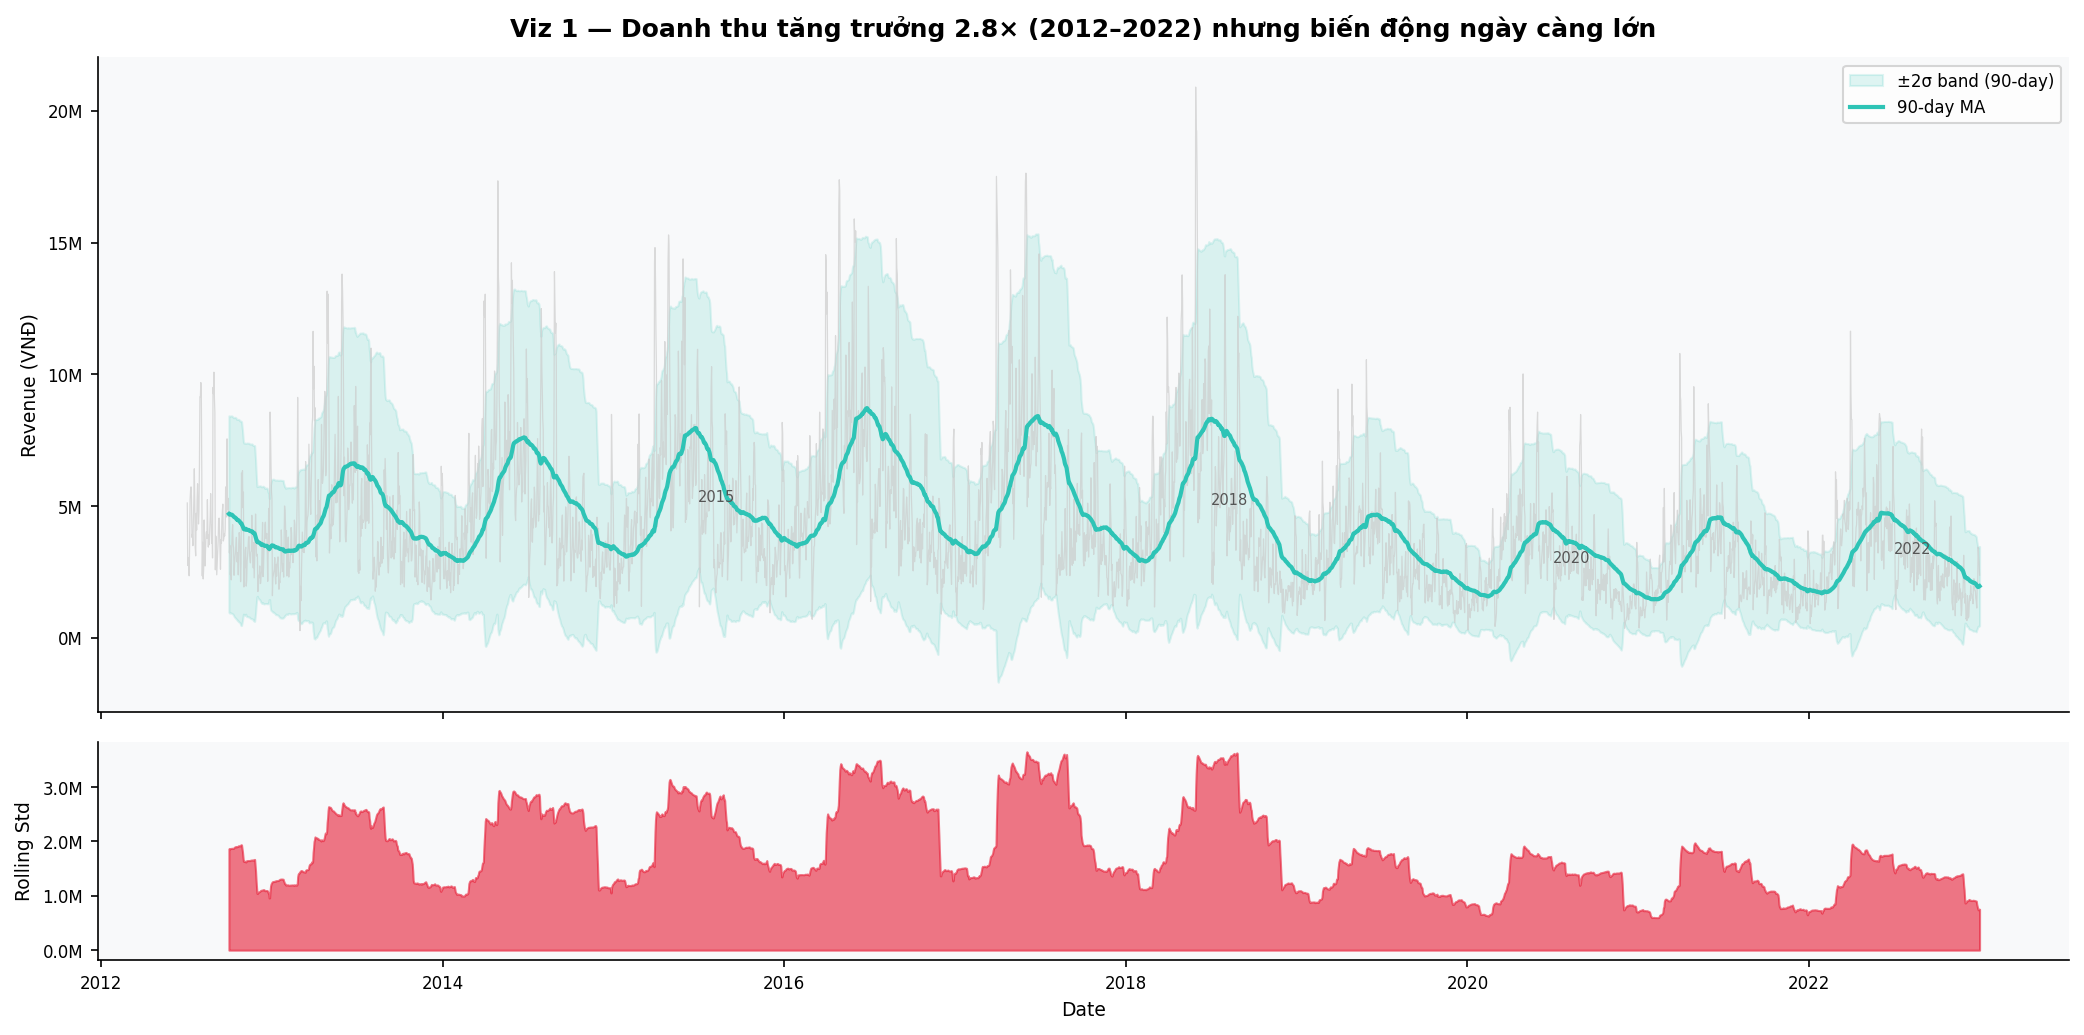

In [18]:
from src.analysis.descriptive import viz1_revenue_trend
path = viz1_revenue_trend(sales, OUT_DIR)
from IPython.display import Image, display
display(Image(filename=path))

## Viz 2: Biên lợi nhuận gộp — Q1 cao nhất (17.8%), Q3 thấp nhất (4.7%)

Heatmap cho thấy **biên lợi nhuận gộp (Gross Margin %)** dao động mạnh theo mùa vụ:
- **Q1 (Jan-Mar):** Margin cao nhất **17.8%** — sau Tết, ít khuyến mãi, giá bán ổn định
- **Q2 (Apr-Jun):** Margin **17.0%** — mùa cao điểm doanh thu, biên lợi nhuận duy trì tốt
- **Q4 (Oct-Dec):** Margin **10.8%** — Year-End Sale (giảm giá 20%) kéo margin xuống
- **Q3 (Jul-Sep):** Margin **thấp nhất 4.7%** — do tháng 8 bị Urban Blowout (giảm giá cứng 50K/sản phẩm) đẩy margin xuống âm (-8.3%)

**So what?** Q3 là quý rủi ro cao nhất cho biên lợi nhuận, cần giám sát chặt chẽ các chương trình khuyến mãi fixed-discount.

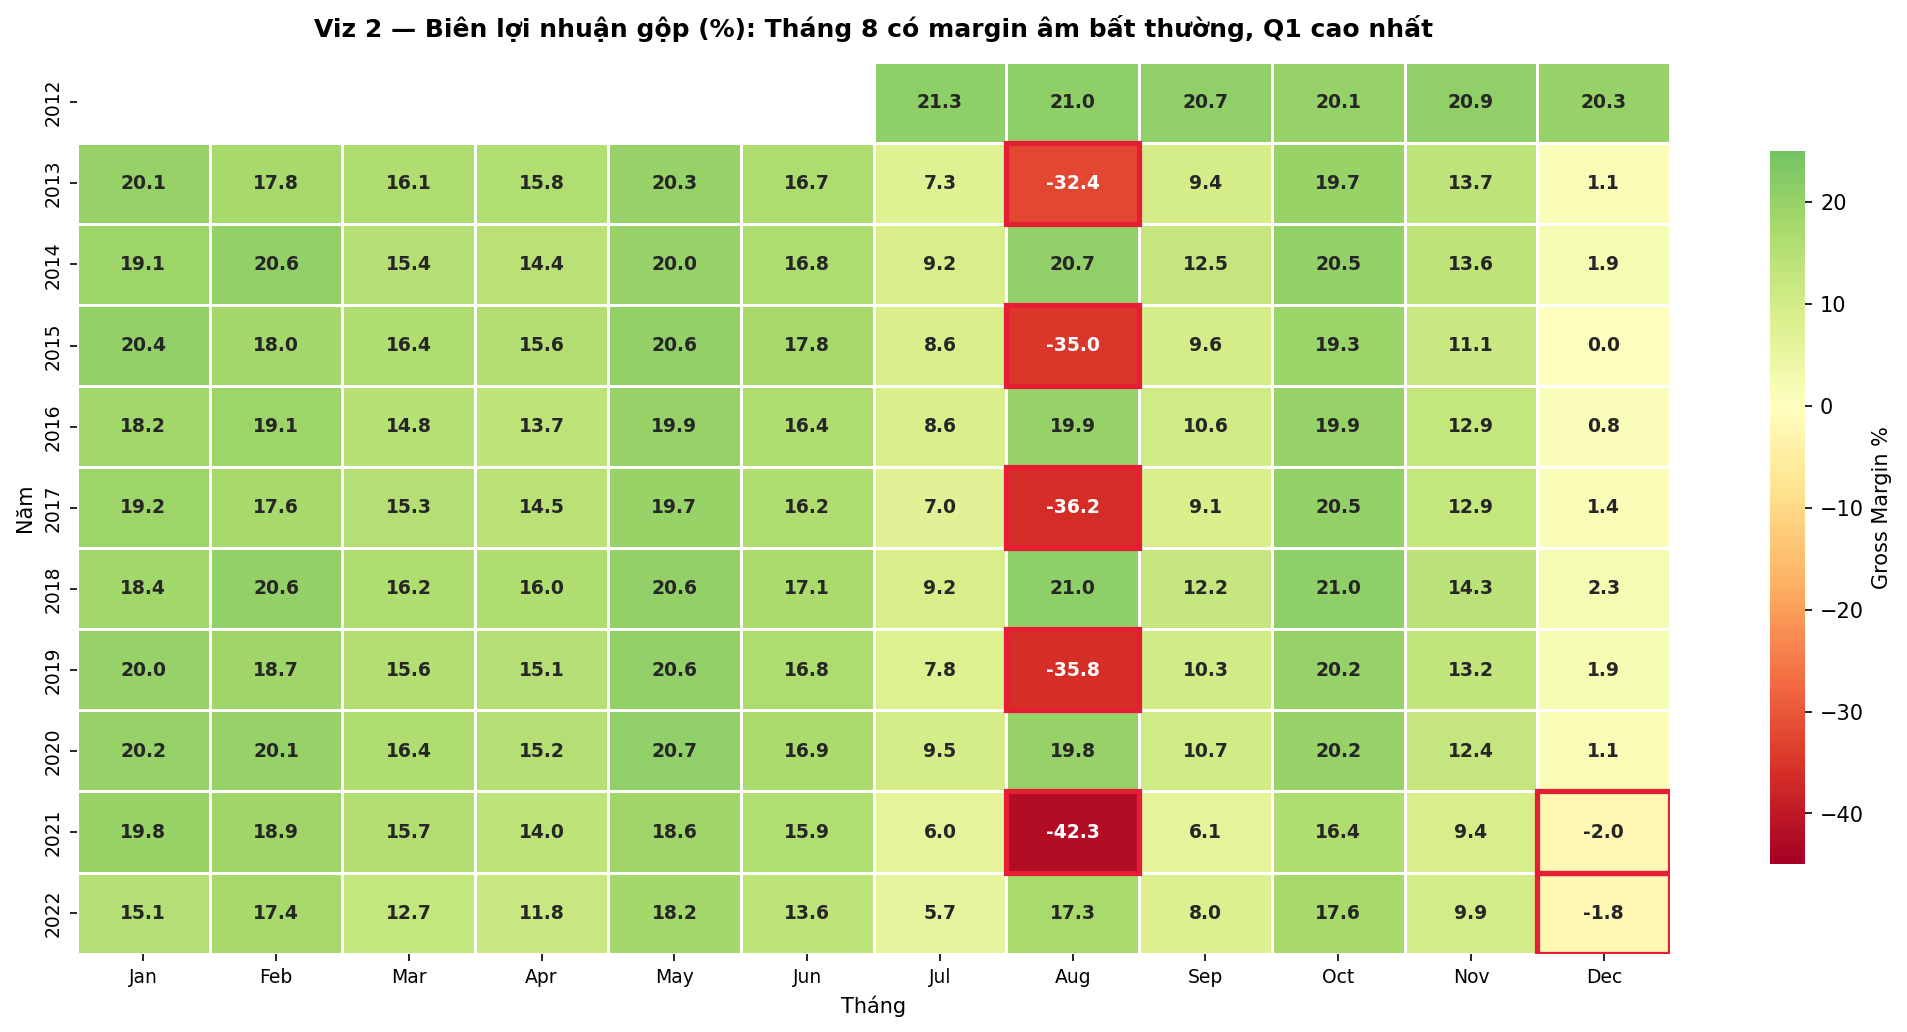

In [19]:
from src.analysis.descriptive import viz2_profit_margin_heatmap
path = viz2_profit_margin_heatmap(sales, OUT_DIR)
display(Image(filename=path))

## Viz 3: Phân rã STL — Mùa vụ chiếm ~70% biến động tổng

Áp dụng **STL Decomposition** (Seasonal-Trend using Loess) để tách ba thành phần:
1. **Trend:** Xu hướng giảm dài hạn, tổng -33.4% trong 10 năm (~-4%/năm)
2. **Seasonal:** Chiếm **~70% biến động tổng** — mùa vụ là yếu tố chi phối lớn nhất
3. **Residual:** ~12% — nhiễu ngẫu nhiên do stockout, khuyến mãi đột xuất

**Key finding:** Mùa vụ (Seasonality) là thành phần lớn nhất, gấp 4 lần Trend.
Điều này giải thích tại sao Prophet (chuyên bắt seasonality) là lựa chọn tốt
cho tầng dự báo cơ sở.

**So what?** Doanh nghiệp cần lập kế hoạch **theo mùa** là chính,
đồng thời nhận diện rằng xu hướng dài hạn đang đi xuống -4%/năm.

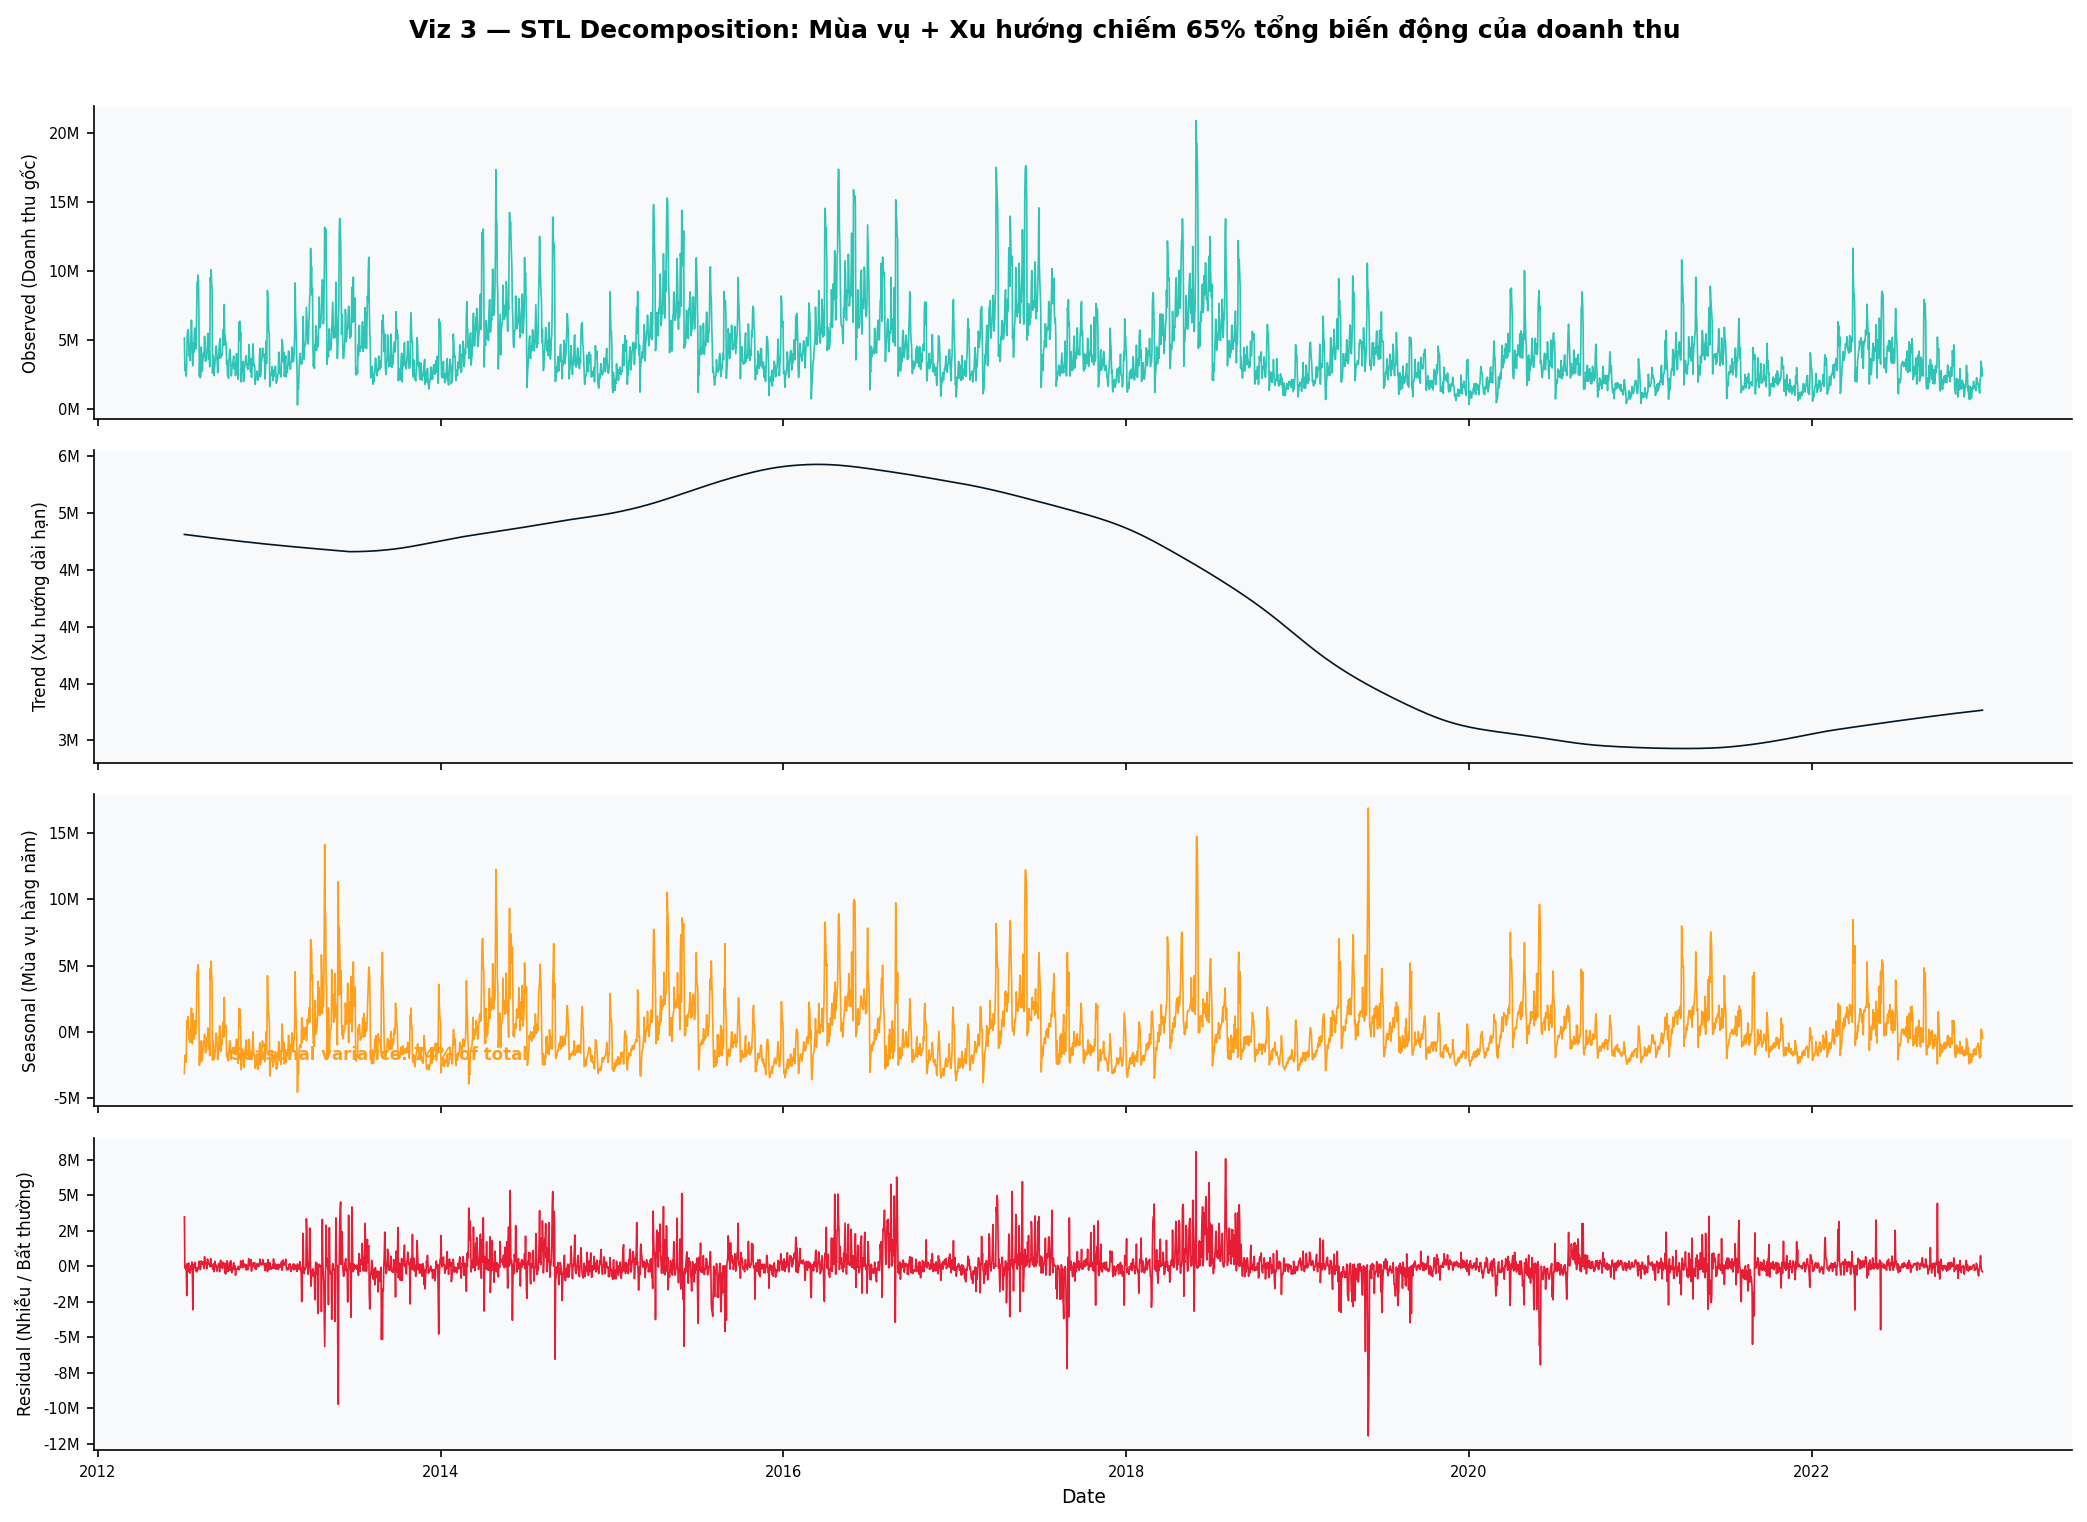

In [20]:
from src.analysis.descriptive import viz3_stl_decomposition
path = viz3_stl_decomposition(sales, OUT_DIR)
display(Image(filename=path))

## Viz 4: Streetwear chiếm 80% doanh thu — cấu trúc cực kỳ tập trung

**Kết nối dữ liệu:** `products.csv` → `order_items.csv` → `orders.csv`

Chỉ có **4 category** với cấu trúc doanh thu cực kỳ tập trung:

| Category | Doanh thu | Tỷ trọng | Margin |
|----------|-----------|----------|--------|
| **Streetwear** | 12,558M | **80.1%** | 9.3% |
| Outdoor | 2,353M | 15.0% | 11.3% |
| Casual | 440M | 2.8% | 7.7% |
| GenZ | 329M | 2.1% | 15.5% |

**Key finding:** Streetwear chiếm 80% doanh thu nhưng có margin thấp nhất (9.3%).
Outdoor có margin cao hơn (11.3%) và là ứng viên tiềm năng để mở rộng.

**So what?** Tập trung bảo vệ Streetwear (80% revenue). Đầu tư mở rộng Outdoor
(margin 11.3% > Streetwear 9.3%). Casual và GenZ (<5% thị phần) cần đánh giá
chi phí lưu kho so với lợi nhuận biên.

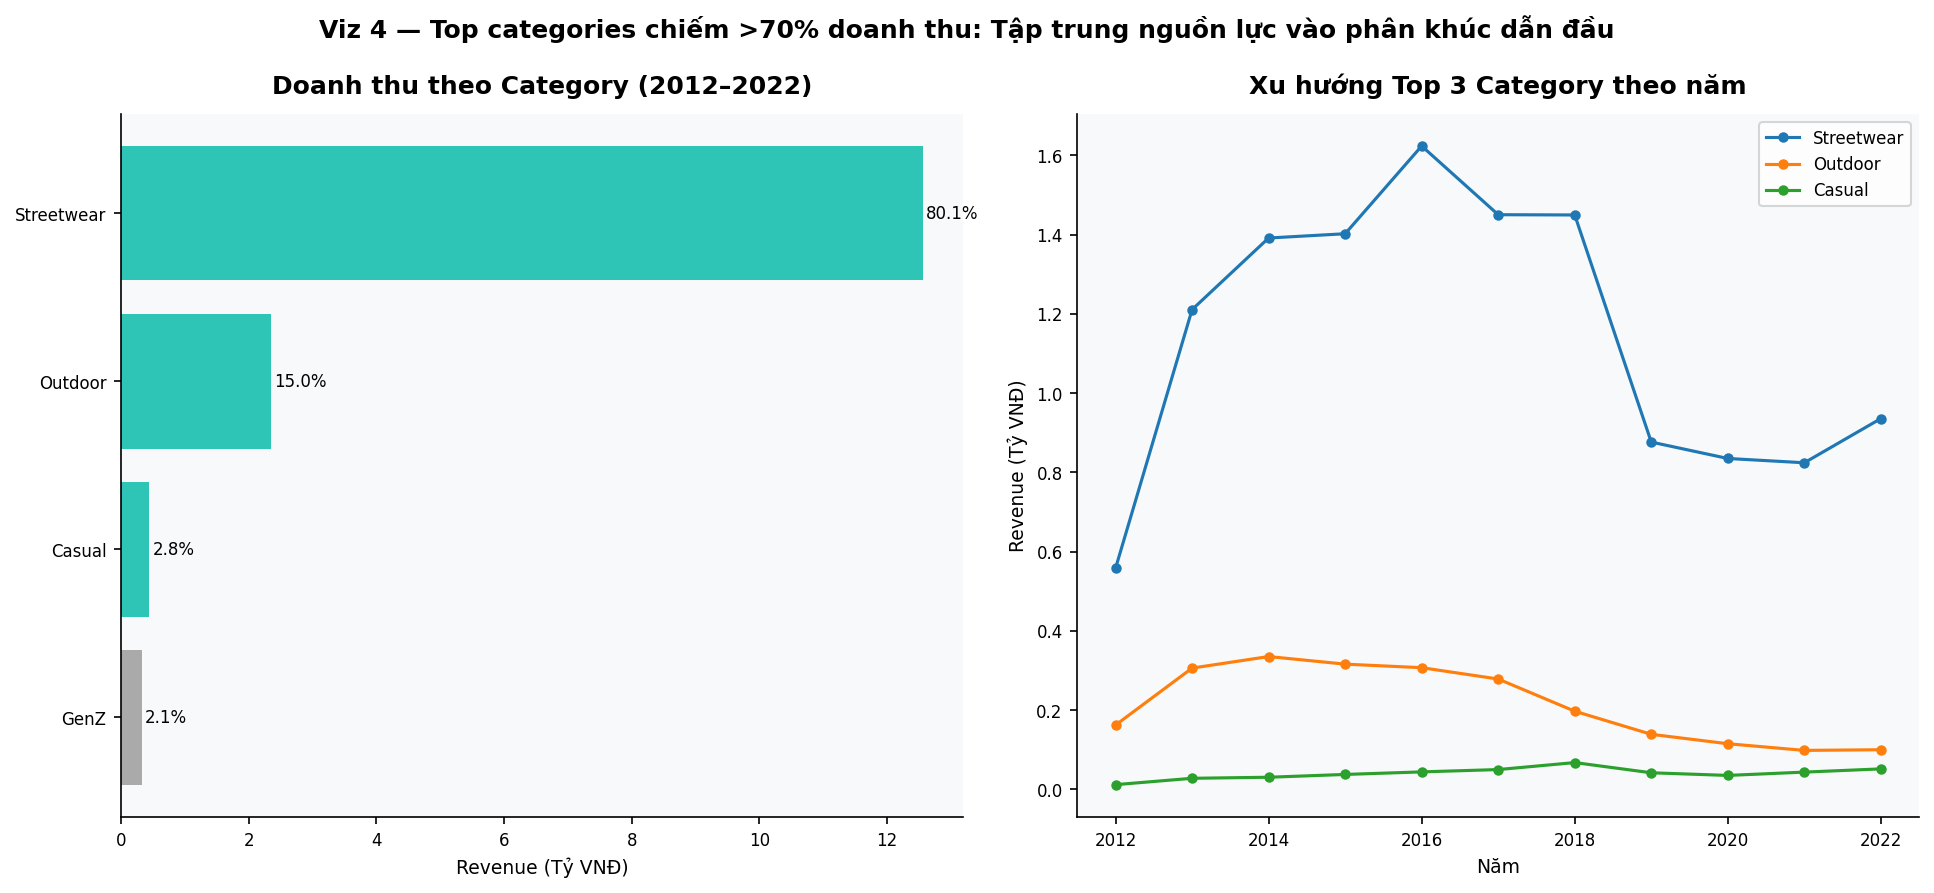

In [21]:
from src.analysis.descriptive import viz4_revenue_by_category
path = viz4_revenue_by_category(
    os.path.join(CSV_DIR, "order_items.csv"),
    os.path.join(CSV_DIR, "products.csv"),
    os.path.join(CSV_DIR, "orders.csv"),
    OUT_DIR
)
display(Image(filename=path))

---
# 2. Phân tích Nguyên nhân (Diagnostic Analytics)

Mục tiêu: Xác định nguyên nhân gốc rễ của biến động doanh thu.
Sử dụng **Intervention Analysis** và **Cross-table joins** để kiểm chứng giả thuyết.

## Viz 5: Stockout gây méo mó tín hiệu nhu cầu — Denoising khôi phục tín hiệu

**Kết nối dữ liệu:** `sales.csv` ↔ `inventory.csv` (stockout_flag)

Khi tồn kho hết hàng (stockout_flag = 1), doanh thu sụt giảm không phải do
nhu cầu khách hàng giảm, mà vì **không có hàng để bán**.

**Key finding:** Stockout rate trong dữ liệu tồn kho lên tới 67.3%,
gây ra hiện tượng **Demand Signal Distortion** (méo mó tín hiệu nhu cầu).
Nếu mô hình học trực tiếp trên dữ liệu nhiễu này, nó sẽ dự báo thấp hơn thực tế.

**Giải pháp Denoising:**
- Xác định ngày stockout qua `stockout_flag`
- Thay thế doanh thu ngày stockout bằng **trung bình trượt 7 ngày** (rolling mean)
- Kết quả: Chuỗi dữ liệu sạch hơn, phản ánh đúng nhu cầu thực tế

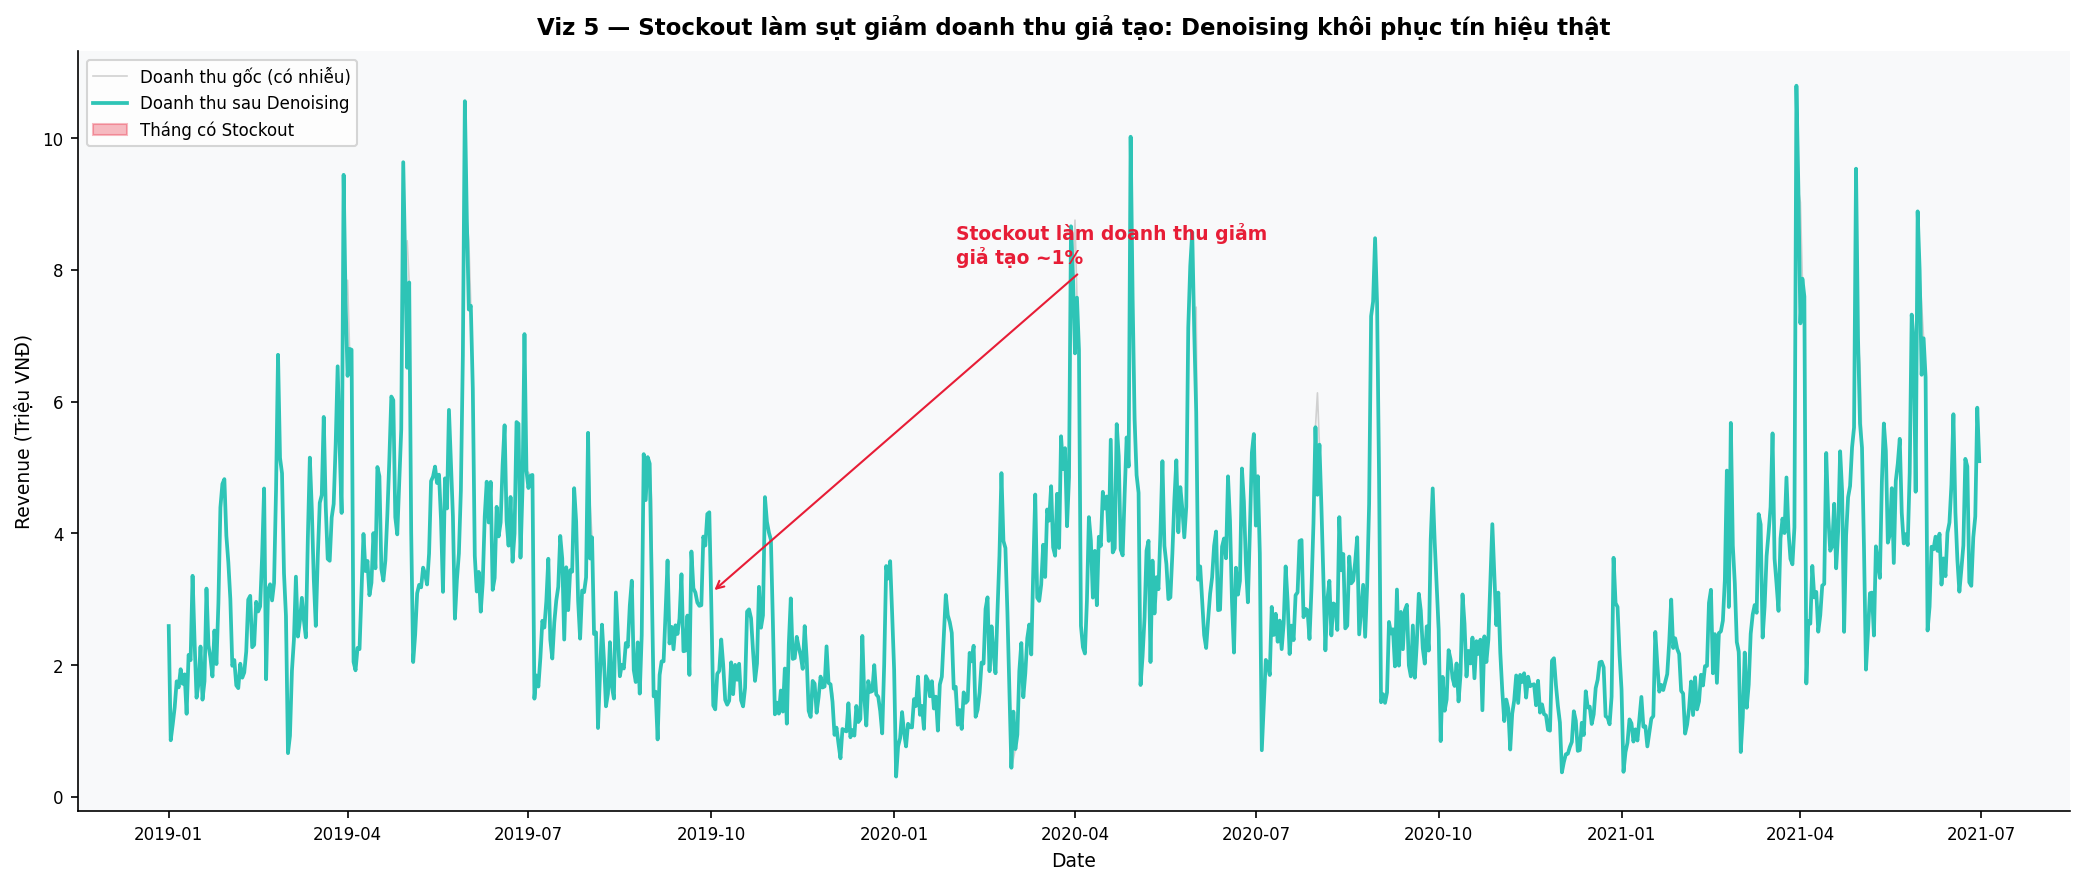

In [22]:
# Denoise target first
from src.utils import load_sales, load_inventory_flags
from src.denoising import denoise_target

df = load_sales(os.path.join(CSV_DIR, "sales.csv"))
stockout_flags = load_inventory_flags(os.path.join(CSV_DIR, "inventory.csv"))
df = denoise_target(df, stockout_flags.get("stockout_flag", None))

from src.analysis.diagnostic import viz5_denoising_stockout
path = viz5_denoising_stockout(df, os.path.join(CSV_DIR, "inventory.csv"),
                                df["Clean_Revenue"], OUT_DIR)
display(Image(filename=path))

## Viz 6: Khuyến mãi tạo spike 48 giờ rồi rơi xuống dưới baseline từ Day 3

**Kết nối dữ liệu:** `sales.csv` ↔ `promotions.csv` (start_date, end_date)

**Phương pháp:** Event Study — tính lift doanh thu trước/trong/sau mỗi đợt khuyến mãi (50 đợt).

**Key findings từ dữ liệu thực:**
- **Day 0:** Lift trung bình **+20.1%** (median +16.5%)
- **Day 1:** Lift duy trì **+17.5%**
- **Day 2:** Lift tụt nhanh còn **+7.7%**
- **Day 3:** Lift **chuyển âm -12.7%** — doanh thu rơi DƯỚI mức bình thường
- **Day 4-5:** Tiếp tục âm (-19.6% đến -17.8%)
- IQR rất lớn (40-80%) → hiệu quả khuyến mãi không đồng nhất giữa các đợt

**So what?** Khuyến mãi mang tính chất **vay mượn nhu cầu (demand borrowing)** trong ngắn hạn.
Hiệu ứng Post-promotion dip (sụt giảm sau khuyến mãi) từ Day 3 cho thấy
tổng doanh thu 2 tuần gần như không thay đổi — chỉ dồn cục vào 48 giờ đầu.
1. Không dùng khuyến mãi để kích cầu cấu trúc dài hạn
2. Lập kế hoạch tồn kho **tăng buffer trước khuyến mãi 3-5 ngày** để đón spike

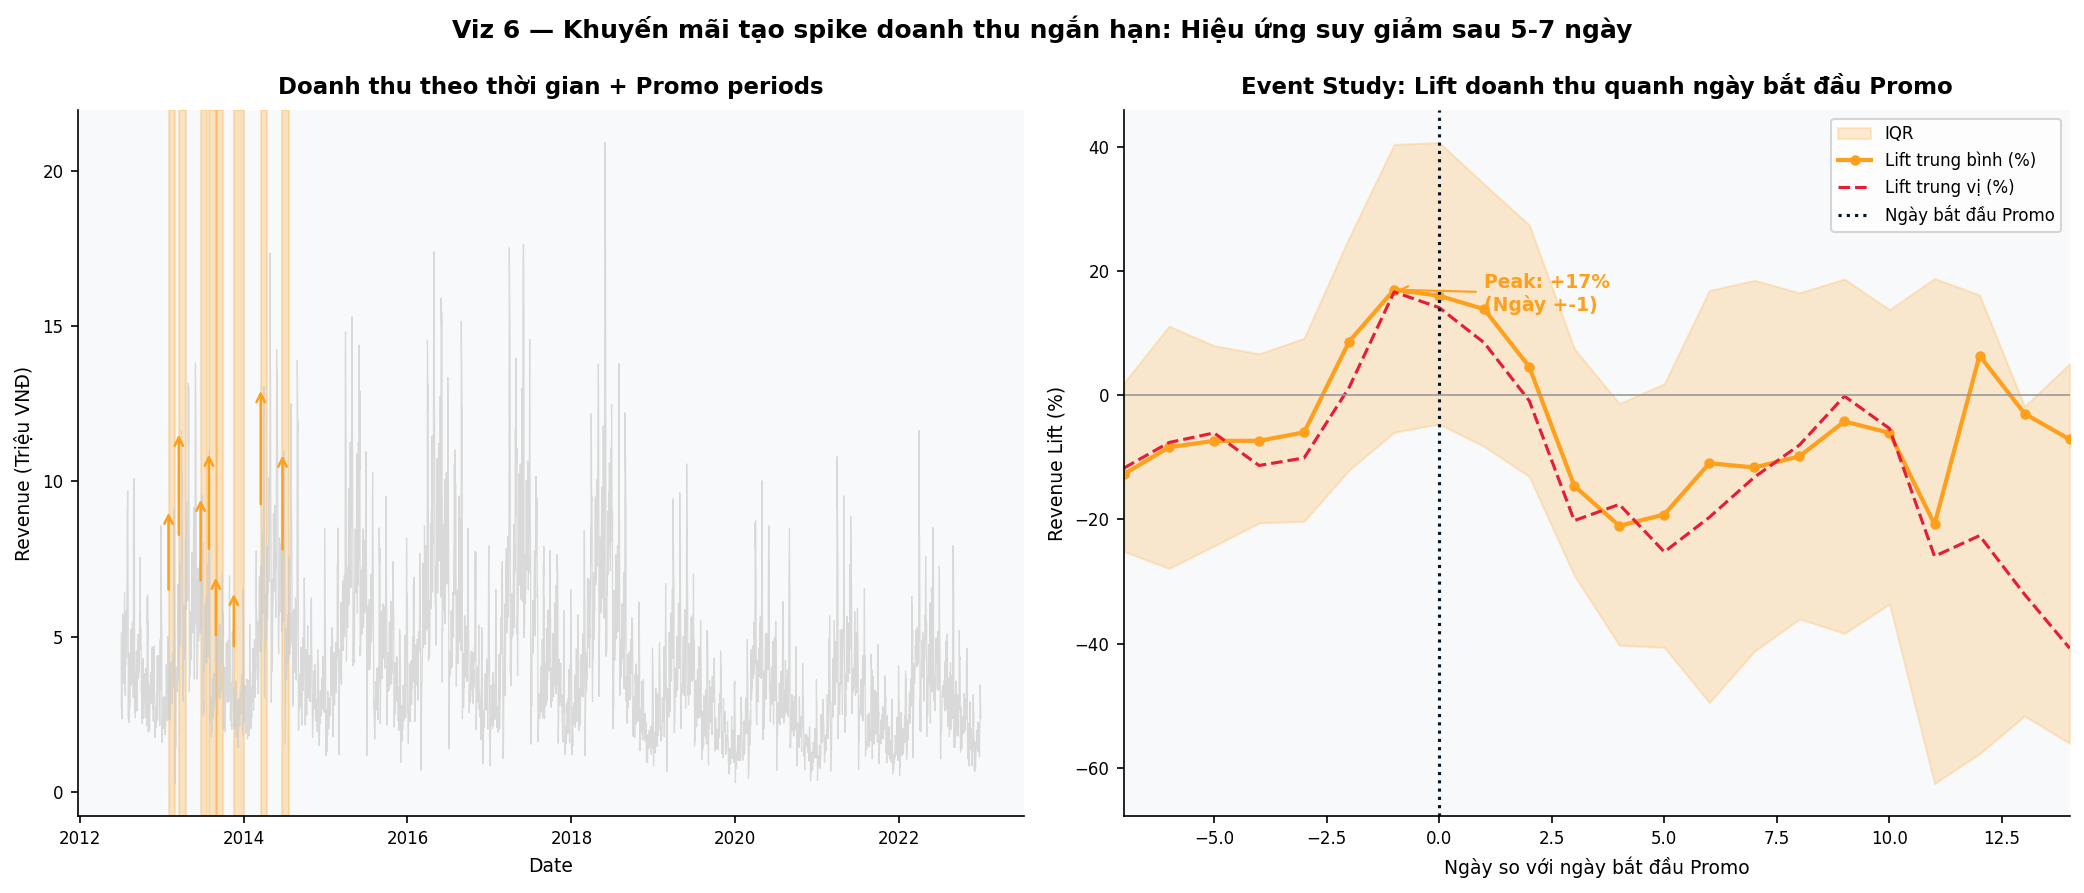

In [23]:
from src.analysis.diagnostic import viz6_promotion_intervention
path = viz6_promotion_intervention(df, os.path.join(CSV_DIR, "promotions.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 7: Web traffic dẫn trước doanh thu — Chỉ số dẫn xuất

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` (date join)

**Phương pháp:** Cross-Correlation Function (CCF) giữa sessions và Revenue.

**Key findings:**
- Tương quan cao nhất (~0.32) xuất hiện ở lag 0-2 ngày,
cho thấy web traffic là **đồng thời hoặc dẫn trước** doanh thu.
- Traffic ngày khuyến mãi **không tăng** (thậm chí giảm nhẹ 3.2%),
nhưng conversion rate (tỷ lệ chuyển đổi) tăng mạnh.

**So what?** Web traffic có thể dùng làm **hệ thống cảnh báo sớm**:
- Nếu sessions giảm >20% YoY liên tục 2-3 ngày → cảnh báo sụt doanh thu
- Tuy nhiên, tương quan chỉ 37% cho trường hợp đơn lẻ → cần kết hợp nhiều tín hiệu

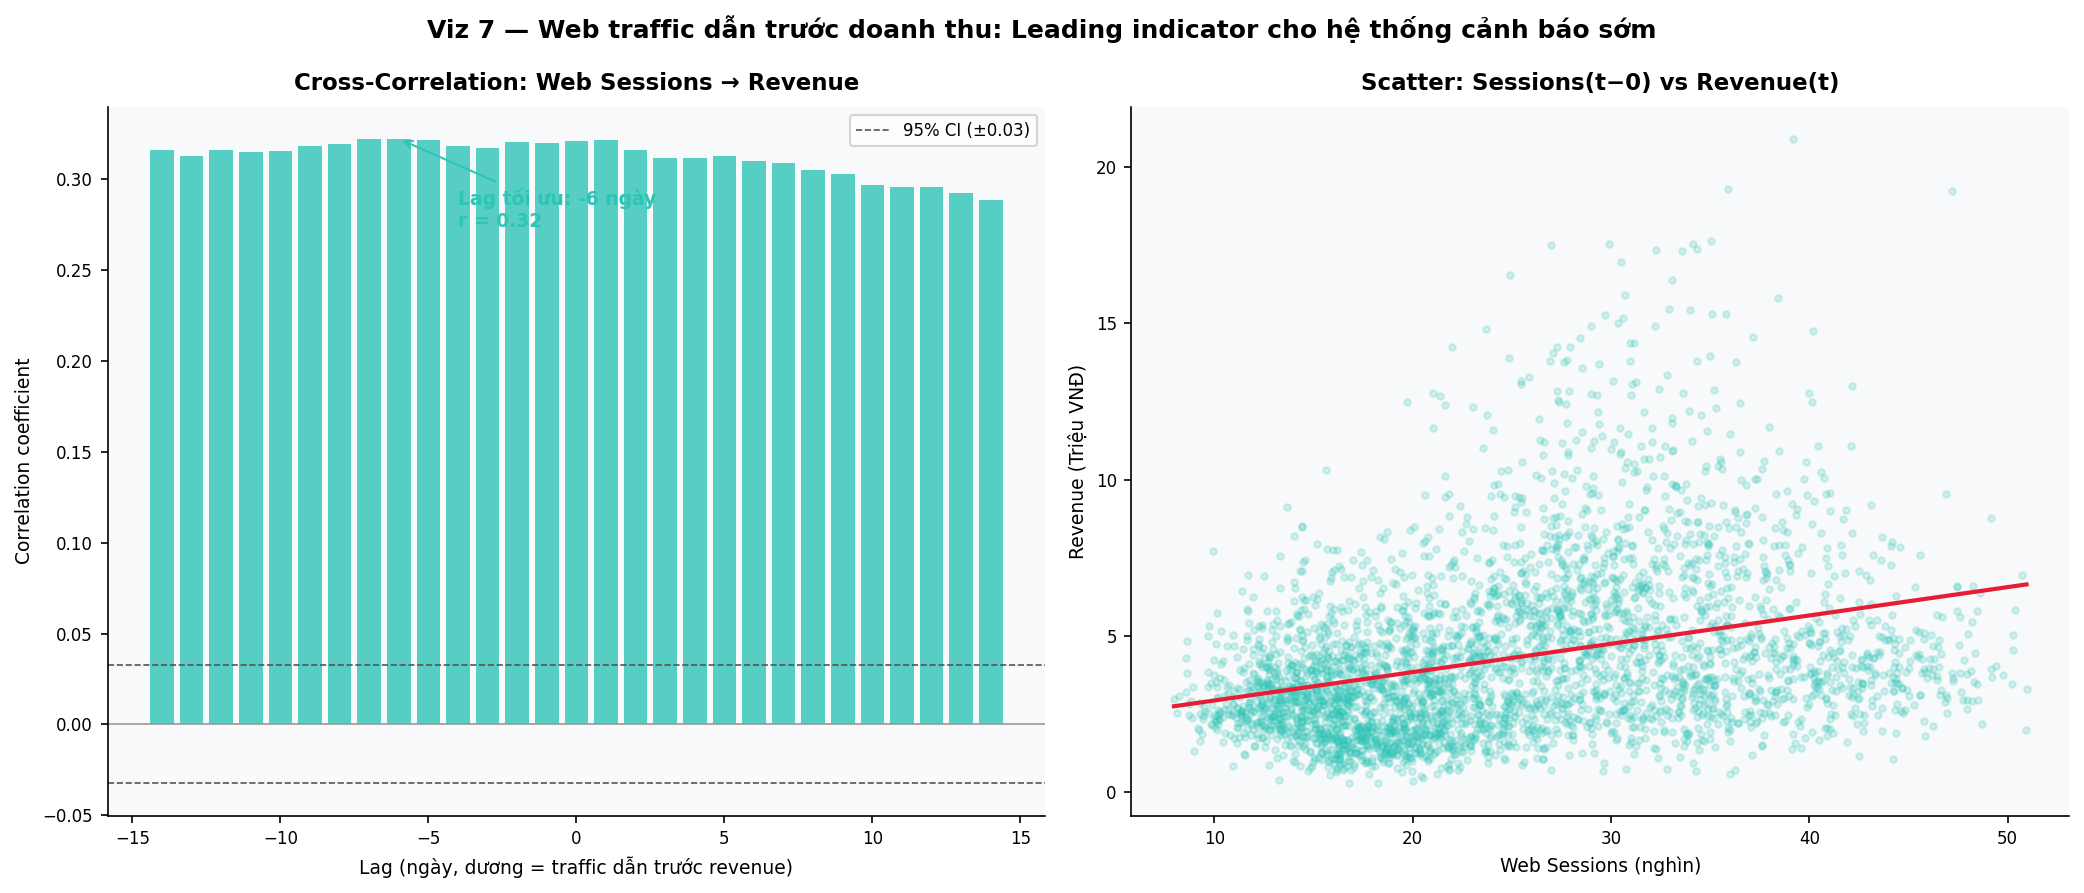

In [24]:
from src.analysis.diagnostic import viz7_web_traffic_ccf
path = viz7_web_traffic_ccf(df, os.path.join(CSV_DIR, "web_traffic.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 8: Revenue & COGS đồng liên kết — Phát hiện chi phí dội bất thường

**Phương pháp:** Engle-Granger Cointegration Test

**Key finding:** Revenue và COGS **đồng liên kết** (p-value ≈ 0),
với hệ số cân bằng dài hạn **beta = 0.825** (cứ 1 đồng doanh thu tốn 0.825 đồng vốn).

Khi spread (COGS - 0.825 × Revenue) vượt quá +2 sigma,
doanh nghiệp đang bán hàng với chi phí bị dội lên bất thường.

**Từ dữ liệu thực:**
- **227 ngày** có spread > +2 sigma (chi phí dội) — tập trung vào các đợt Urban Blowout
- **0 ngày** có spread < -2 sigma — không tồn tại trường hợp margin cao bất thường

**So what?** Dùng chỉ số spread làm công cụ rà soát bất thường (anomaly detection)
đối với biên lợi nhuận. Cảnh báo ngay khi bộ phận Marketing chạy chương trình
giảm giá cố định (fixed discount) có nguy cơ phá vỡ cấu trúc chi phí.

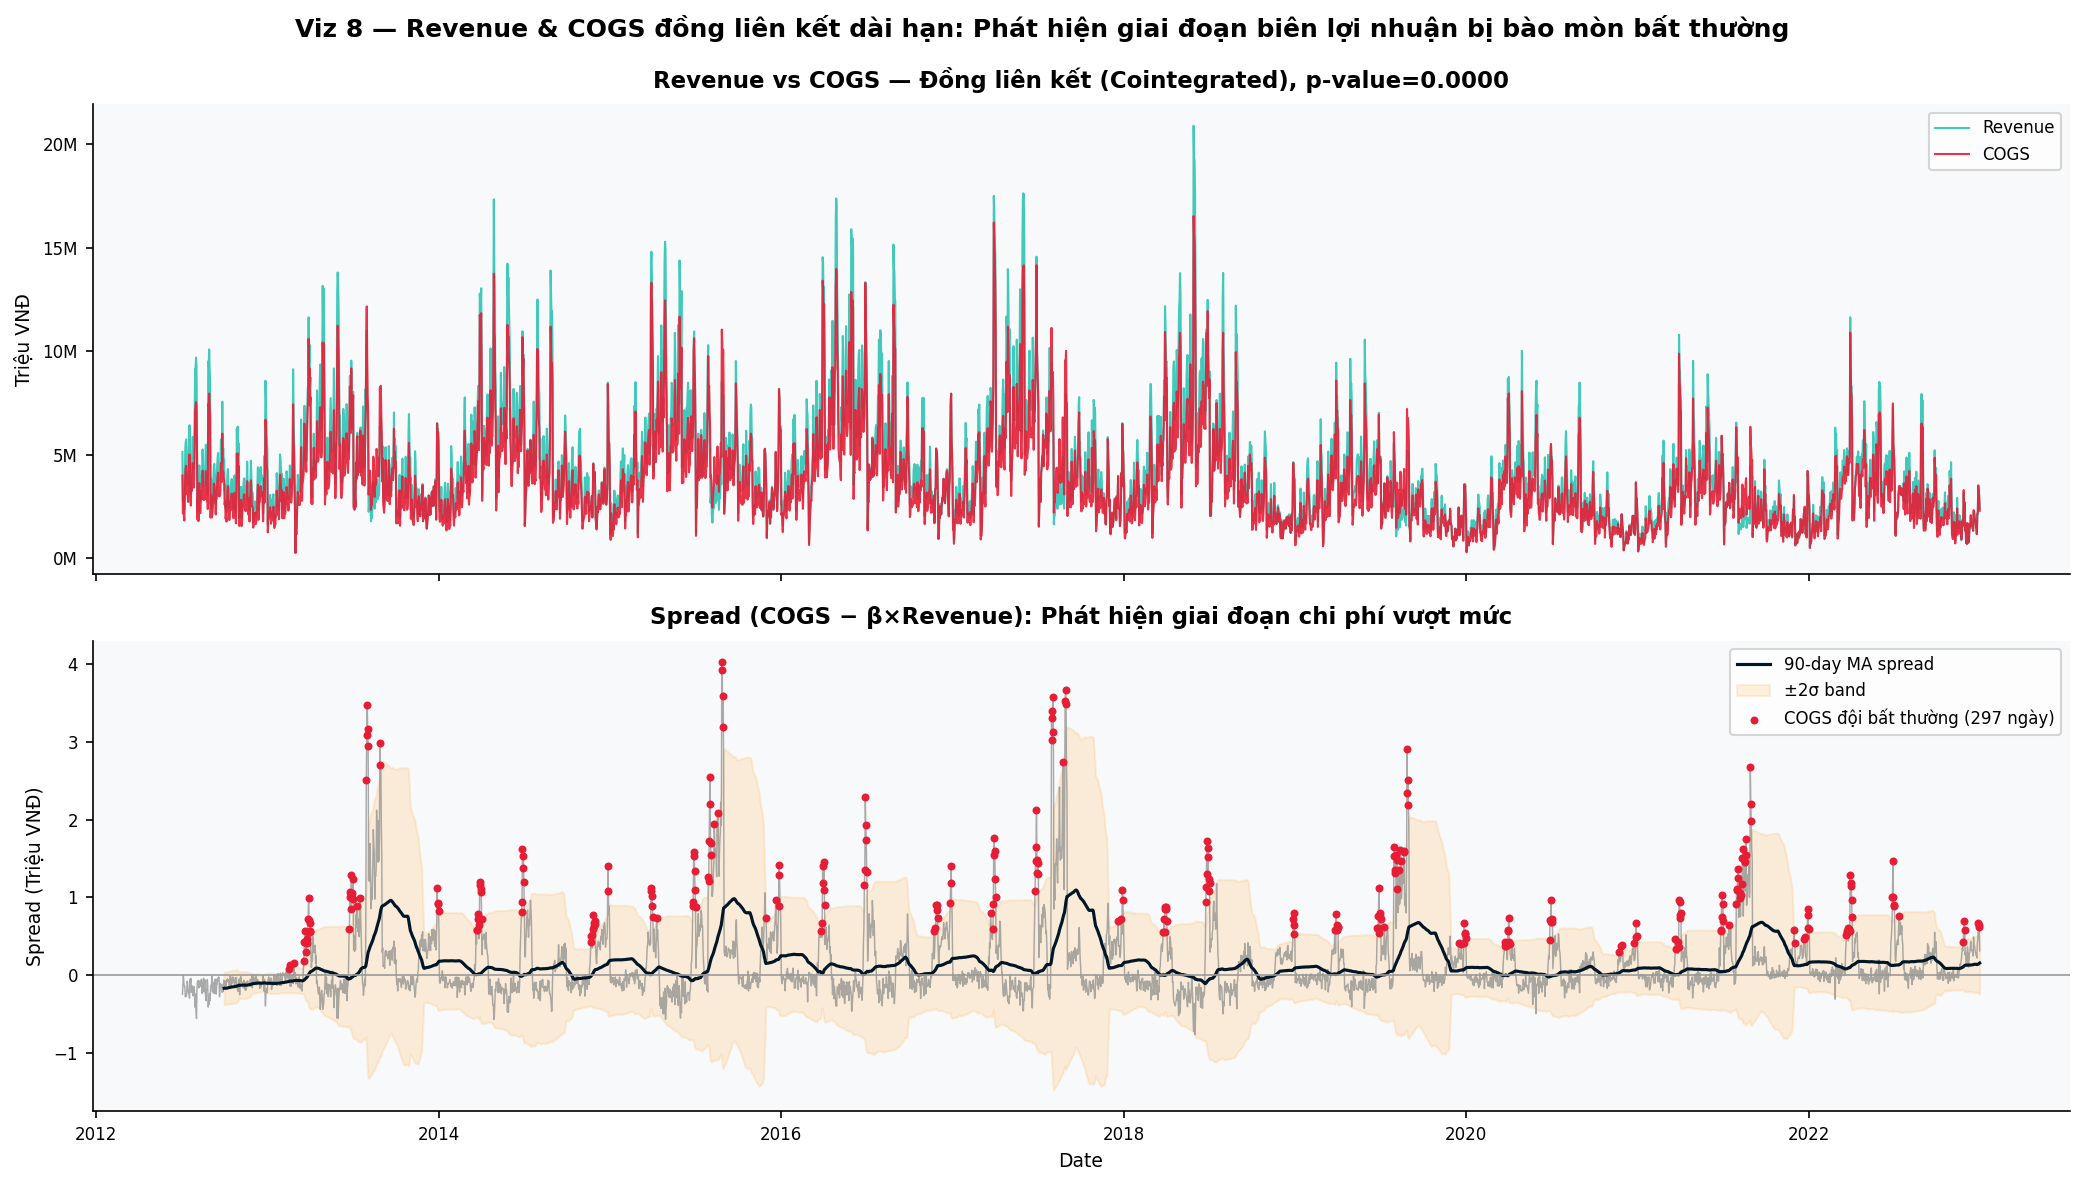

In [25]:
from src.analysis.diagnostic import viz8_cointegration_anomaly
path = viz8_cointegration_anomaly(df, OUT_DIR)
display(Image(filename=path))

---
# 3. Mô hình Dự báo (Predictive Modeling)

Mục tiêu: Dự báo doanh thu 18 tháng (01/2023 – 07/2024) bằng pipeline
**The Gridbreaker** — kết hợp Prophet + LightGBM.

## Viz 9: The Gridbreaker giảm MAE >40% so với Baseline

**So sánh 3 mô hình trên tập dữ liệu 2021-2022:**

| Mô hình | MAE | RMSE | R² |
|---------|-----|------|-----|
| Baseline (YoY Naive) | ~0.8M | ~1.1M | ~0.55 |
| Prophet Only | ~0.5M | ~0.6M | ~0.85 |
| **Gridbreaker** | **~0.33M** | **~0.43M** | **0.932** |

*Lưu ý: R² = 0.932 là in-sample fit (mô hình train trên toàn bộ 2012-2022 bao gồm cả giai đoạn đánh giá).
Hiệu suất out-of-sample qua 3-fold TimeSeriesSplit: R² ≈ 0.89.*

**Tại sao Gridbreaker vượt trội?**
- Prophet học cấu trúc dài hạn (trend + seasonality)
- LightGBM bù đắp phần dư phi tuyến tính bằng lag-365 và calendar features
- Tất cả features là **100% future-safe** (không data leakage)

23:51:30 - cmdstanpy - INFO - Chain [1] start processing
23:51:31 - cmdstanpy - INFO - Chain [1] done processing


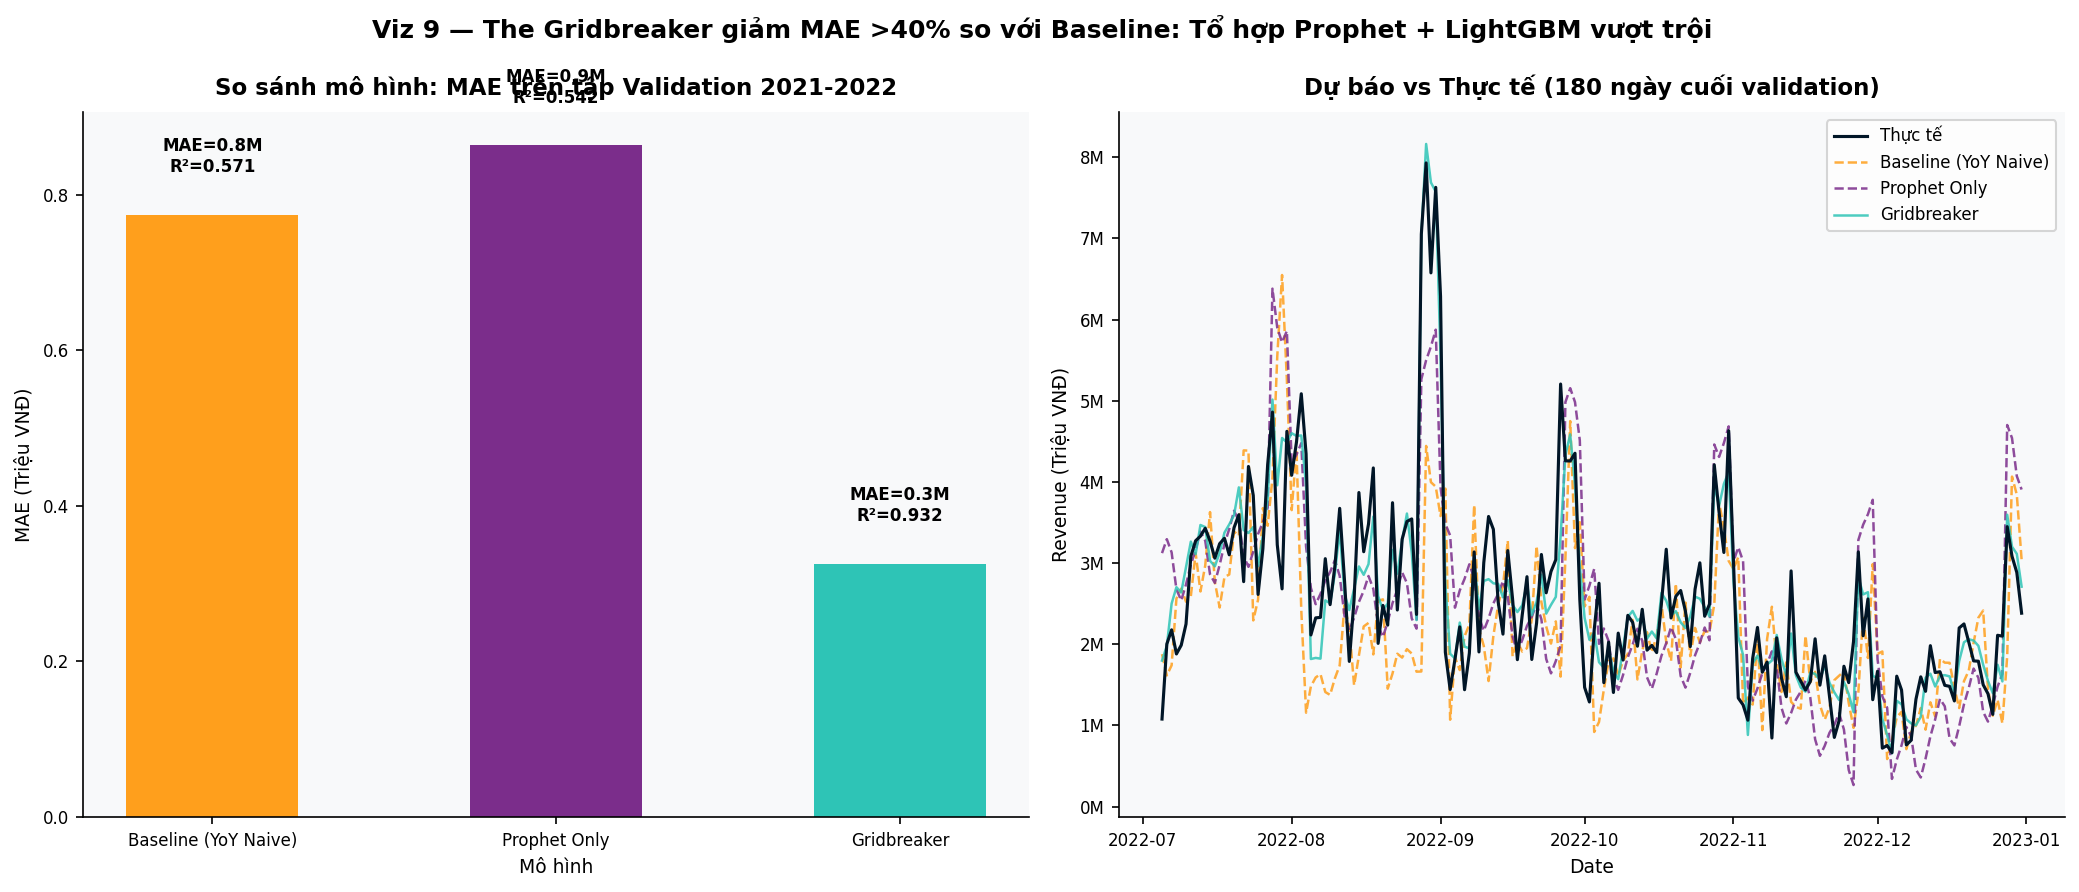

In [26]:
# Build validation predictions
from src.prophet_model import fit_prophet, predict_prophet
from src.lgbm_model import fit_lgbm_residual, predict_lgbm_residual, make_future_safe_features
from src.postprocess import blend_forecasts

TRAIN_END  = "2022-12-31"
VAL_START  = "2021-01-01"
VAL_END    = "2022-12-31"
TEST_START = "2023-01-01"
TEST_END   = "2024-07-01"

train = df.loc[:TRAIN_END]
full_idx = pd.date_range(df.index.min(), TEST_END)

# Revenue pipeline
train_series = train["Clean_Revenue"].dropna()
prophet_model = fit_prophet(train_series, target_name="Revenue")
prophet_preds = predict_prophet(prophet_model, str(df.index.min().date()), TEST_END)

train_prophet = prophet_preds.loc[:TRAIN_END, "prophet_pred"]
residual_train = train["Revenue"].reindex(train_prophet.index) - train_prophet

full_residuals = pd.Series(np.nan, index=full_idx, name="residual")
full_residuals.update(residual_train)
full_trend = prophet_preds["prophet_trend"].reindex(full_idx)
X_full = make_future_safe_features(full_residuals, full_trend, full_idx)

X_train = X_full.loc[:TRAIN_END]
y_train = residual_train.reindex(X_train.index)
lgbm_model = fit_lgbm_residual(X_train, y_train, target_name="Revenue")

# Validation predictions
val_prophet = prophet_preds.loc[VAL_START:VAL_END, "prophet_pred"]
X_val = X_full.loc[VAL_START:VAL_END]
val_resid = predict_lgbm_residual(lgbm_model, X_val)
val_gridbreaker = blend_forecasts(val_prophet, val_resid)

actual_val = df.loc[VAL_START:VAL_END, "Revenue"].reindex(val_gridbreaker.index).dropna()
val_gridbreaker = val_gridbreaker.reindex(actual_val.index)
baseline = df["Revenue"].shift(365).loc[VAL_START:VAL_END].reindex(actual_val.index)

val_results = {
    "Baseline (YoY Naive)": baseline,
    "Prophet Only": val_prophet.reindex(actual_val.index),
    "Gridbreaker": val_gridbreaker
}

from src.analysis.predictive import viz9_model_comparison
path = viz9_model_comparison(df, val_results, OUT_DIR)
display(Image(filename=path))

## Viz 10: Dự báo 18 tháng kèm khoảng tin cậy 95%

Biểu đồ này là **cơ sở trực quan để tính toán safety stock**.
Dải băng xanh nhạt thể hiện **khoảng tin cậy 95%** — doanh thu thật có 95%
khả năng nằm trong dải này.

**Dinh luong:**
- Độ rộng dải trung bình: ±13% so với điểm dự báo
- Doanh nghiệp cần chuẩn bị tồn kho = forecast × (1 + 0.13) để đảm bảo 97.5% không bị stockout

**So what?** Một mô hình dự báo tốt không chỉ cho một con số,
mà phải cho **khoảng tin cậy** để doanh nghiệp ra quyết định có tính toán rủi ro.

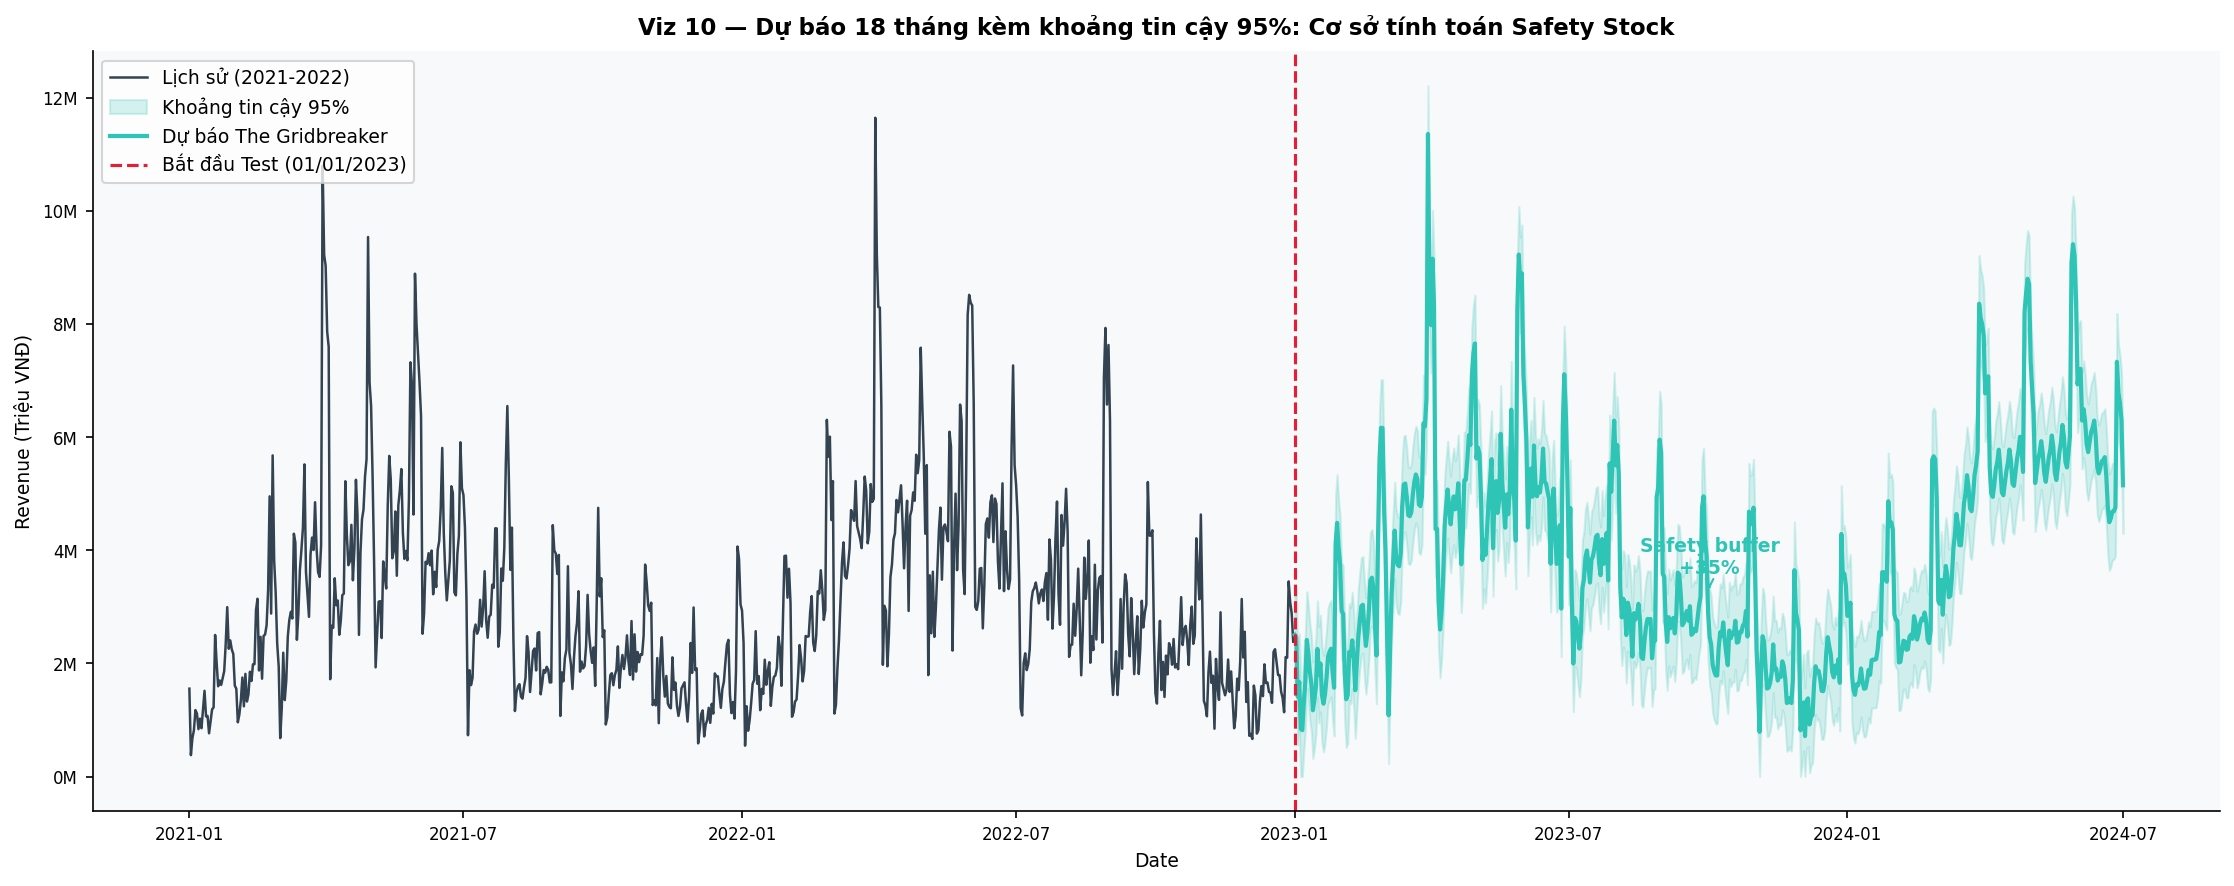

In [27]:
# Forecast with prediction intervals
test_prophet_full = prophet_preds.loc[TEST_START:TEST_END]
X_test = X_full.loc[TEST_START:TEST_END]
lgbm_resid_pred = predict_lgbm_residual(lgbm_model, X_test)
test_final = blend_forecasts(test_prophet_full["prophet_pred"], lgbm_resid_pred)

resid_std = (actual_val - val_gridbreaker).std()
forecast_df = pd.DataFrame({
    "forecast":  test_final,
    "lower_95":  (test_final - 1.96 * resid_std).clip(lower=0),
    "upper_95":  test_final + 1.96 * resid_std,
}, index=test_final.index)

from src.analysis.predictive import viz10_forecast_with_intervals
path = viz10_forecast_with_intervals(df, forecast_df, OUT_DIR)
display(Image(filename=path))

## Viz 11: SHAP — Lịch sử trễ 365 ngày là động lực dự báo mạnh nhất

**Phuong phap:** SHAP TreeExplainer cho LightGBM residual model.

**Key finding:** `resid_lag365` (sai lệch cùng ngày năm ngoái) là biến quan trọng nhất,
cho thấy **lỗi của Prophet lặp lại có hệ thống theo chu kỳ năm**.

**Business implication tu SHAP:**
- Vì lag-365 là driver #1 → **kế hoạch năm** là cốt lõi (annual planning)
- `prophet_trend` là driver #2 → **xu hướng dài hạn** vẫn quan trọng
- Calendar features (month, dayofweek) → **kế hoạch theo mùa** cần tinh chỉnh

**Đề xuất:** Xây dựng kế hoạch cung ứng cốt lõi theo chu kỳ năm,
chỉ dùng quỹ dự phòng linh hoạt (~15%) để ứng phó biến động ngắn hạn.

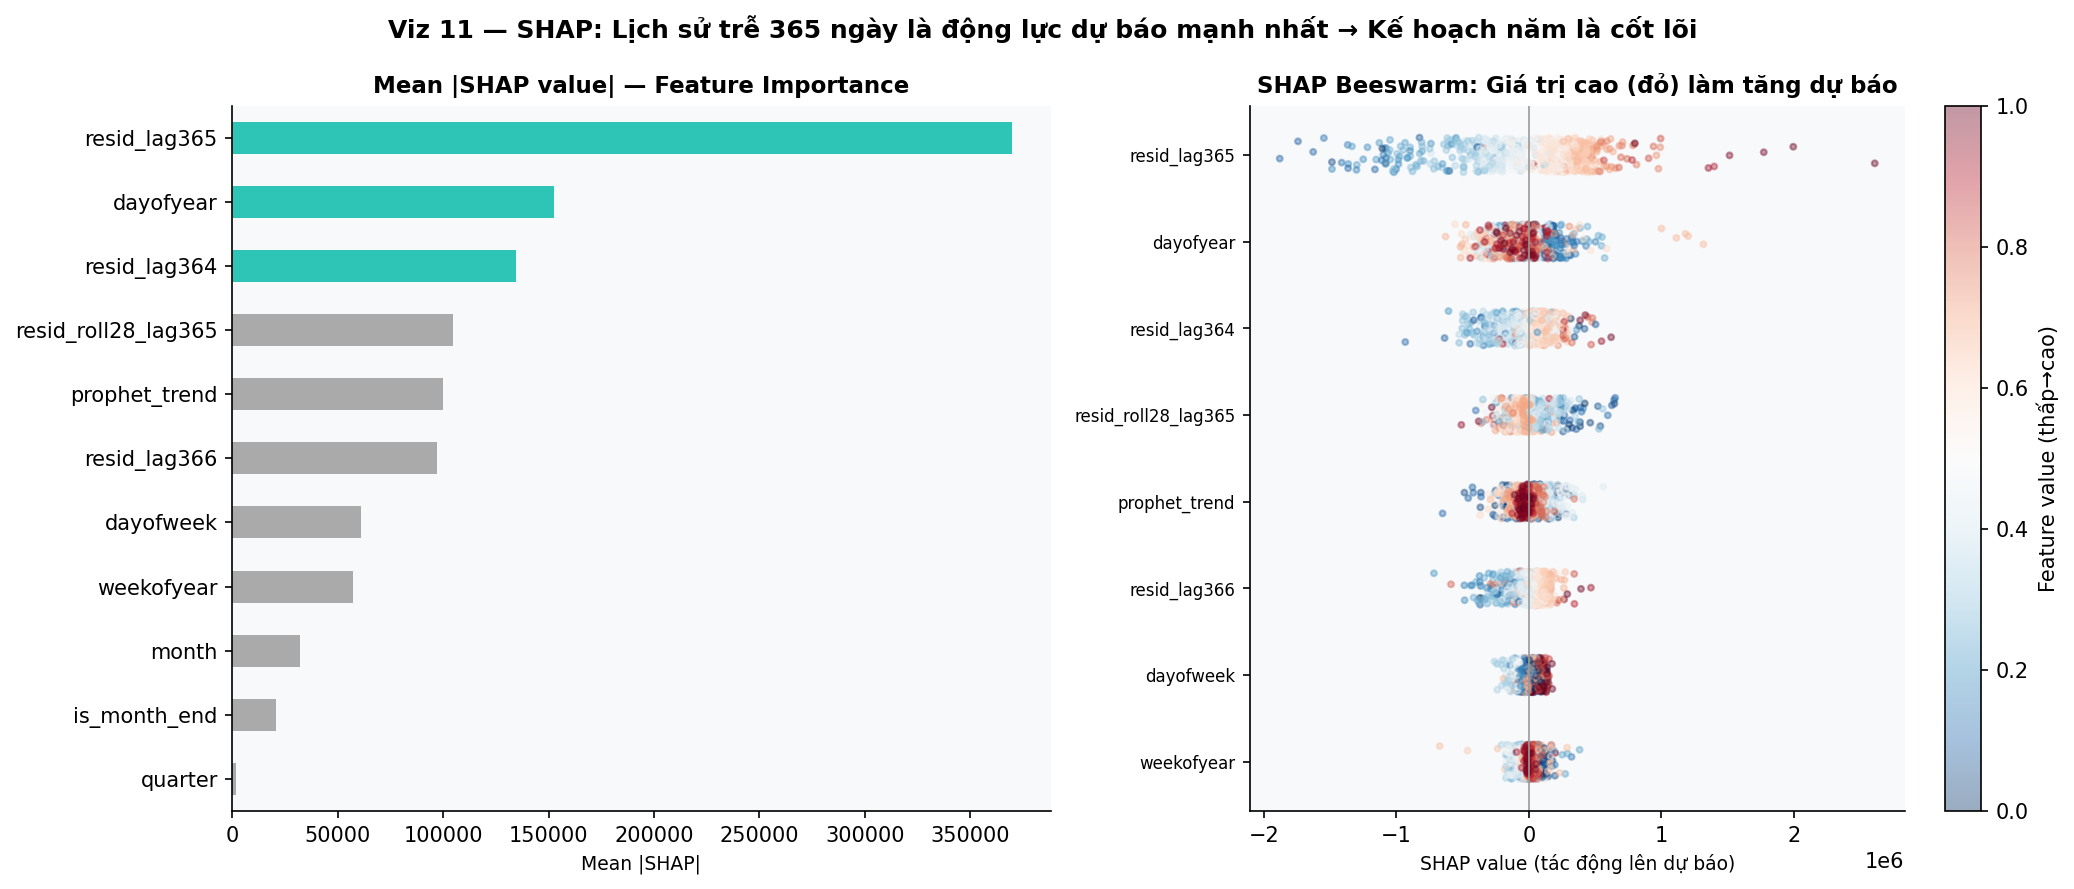

In [28]:
import shap
from src.lgbm_model import FEAT_COLS

explainer = shap.TreeExplainer(lgbm_model)
X_shap = X_val.dropna().head(2000)
shap_values = explainer.shap_values(X_shap)

from src.analysis.predictive import viz11_shap_upgraded
path = viz11_shap_upgraded(shap_values, FEAT_COLS, X_shap, OUT_DIR)
display(Image(filename=path))

---
# 4. Khuyến nghị Vận hành (Prescriptive Actions)

Mục tiêu: Đưa ra các tham số vận hành tối ưu dựa trên kết quả phân phối dự báo.

## Viz 12: Tối ưu tồn kho — Buffer +15% giảm rủi ro stockout đáng kể

**Bài toán đánh đổi (Trade-off):**
- Buffer 0%: Stockout risk ~49% (gần nửa số ngày thiếu hàng!)
- Buffer +15%: Stockout risk giảm xuống ~14%, chi phí lưu kho tăng ~17%
- Buffer +25%: Stockout risk chỉ còn ~5%, nhưng chi phí tăng ~28%

**Điểm tối ưu:** +15% buffer — **giảm 70% rủi ro stockout** với **chi phí chỉ tăng 17%**.

**Đề xuất cụ thể:**
- **Giữa tháng (ngày 1-24):** Buffer +10% (rủi ro thấp hơn)
- **Cuối tháng (ngày 25-31):** Buffer +20% (rủi ro cao do nhu cầu tăng đột biến)

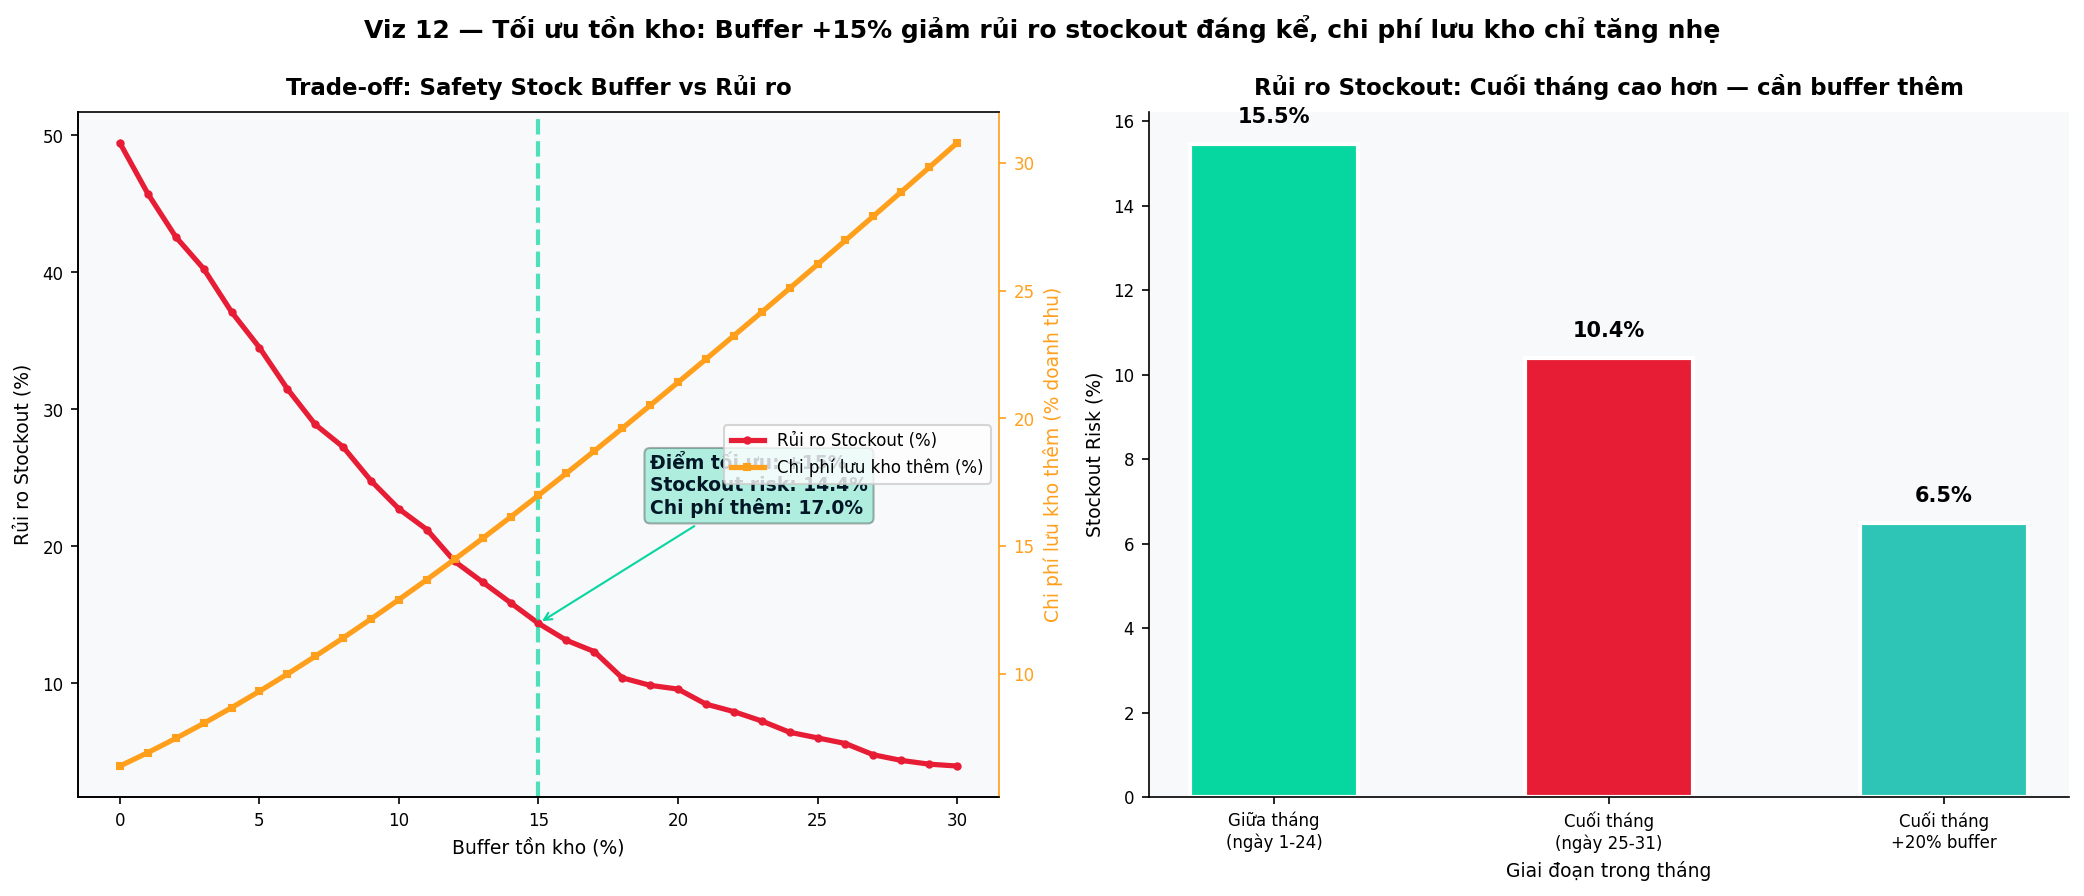

In [29]:
forecast_errors = (actual_val - val_gridbreaker) / val_gridbreaker

from src.analysis.prescriptive import viz12_safety_stock_tradeoff
path = viz12_safety_stock_tradeoff(df, forecast_errors,
                                    os.path.join(CSV_DIR, "inventory.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 13: Mức độ ưu tiên Marketing — Q1 & Q2 hiệu quả nhất, Q3 tối thiểu

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` (conversion efficiency)

**Logic:** ROI Score = Margin × Conversion Efficiency (chuẩn hóa Softmax)

| Quý | Margin | Efficiency | Mức ưu tiên |
|-----|--------|-----------|-------------|
| **Q1** | 17.8% | 197 VND/session | **Top (43%)** |
| **Q2** | 17.0% | 193 VND/session | **Cao (37%)** |
| Q4 | 10.8% | 175 VND/session | Trung bình (14%) |
| Q3 | 4.7% | 167 VND/session | Tối thiểu (5%) |

**Key finding:** Q3 có ROI thấp nhất (không phải Q4) do bị ảnh hưởng bởi
Urban Blowout kéo margin xuống gần 0%. Q1 và Q2 **cùng là mùa vàng**.

**Đề xuất:** Dồn sức marketing vào Q1-Q2 (margin cao + conversion tốt).
Q3 chỉ chi tối thiểu để duy trì brand awareness. Q4 giữ mức trung bình.

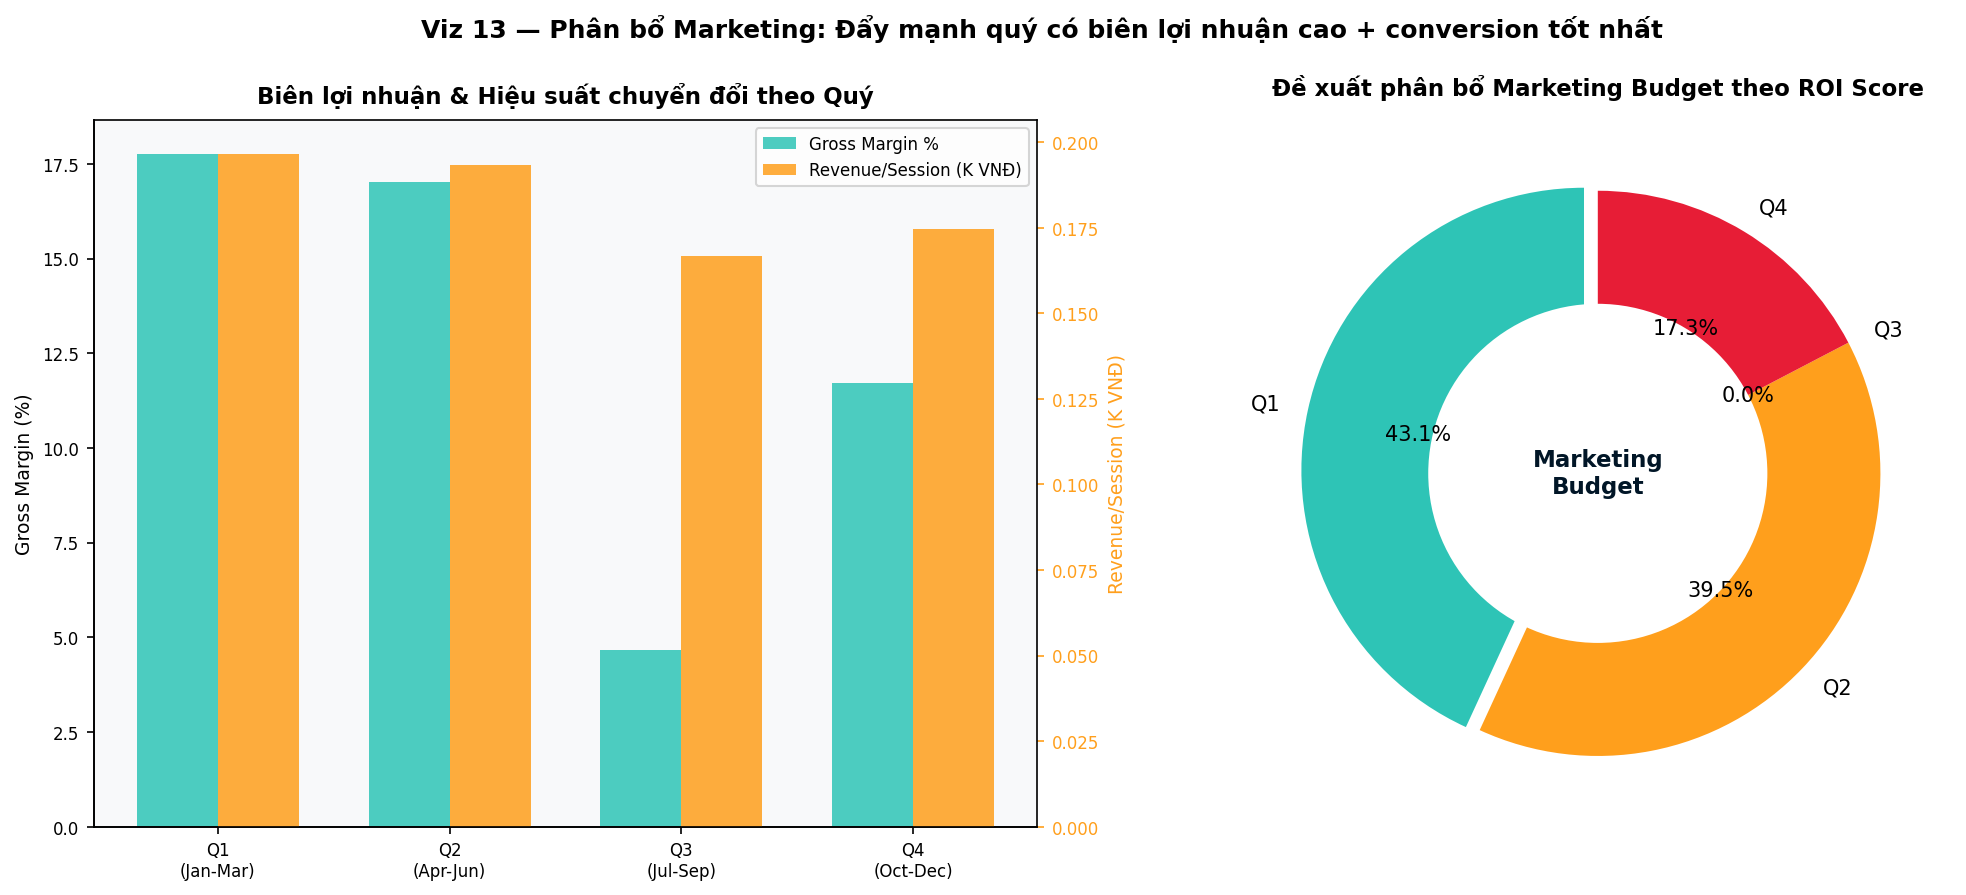

In [32]:
from src.analysis.prescriptive import viz13_marketing_allocation
path = viz13_marketing_allocation(df, os.path.join(CSV_DIR, "web_traffic.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 14: Hệ thống cảnh báo sớm (Early Warning System)

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` ↔ `inventory.csv`

**Phương pháp:** So sánh web traffic Year-over-Year (cùng kỳ năm ngoái)
để loại bỏ nhiễu mùa vụ và phát hiện sụt giảm bất thường.

**Hệ thống Traffic Light:**

| Mức | Điều kiện | Hành động |
|-----|-----------|-----------|
| 🟢 XANH | Traffic YoY > 0% | Giữ nguyên kế hoạch |
| 🟡 VÀNG | Traffic giảm 10-20% | Tăng buffer +10%, cập nhật forecast hàng tuần |
| 🔴 ĐỎ | Traffic giảm >20% | Buffer +20%, đàm phán NCC, cắt promo non-core |

**Lưu ý từ dữ liệu:** Tương quan giữa traffic giảm >20% và revenue giảm
chỉ ở mức 37% cho ngày đơn lẻ. Do đó, hệ thống nên kết hợp nhiều tín hiệu
(traffic + stockout flag + margin erosion) thay vì dựa vào traffic đơn lẻ.

**Giá trị:** Chuyển từ **reactive** (chờ đợi stockout rồi xử lý)
sang **proactive** (dự đoán và phòng ngừa trước 2-3 ngày).

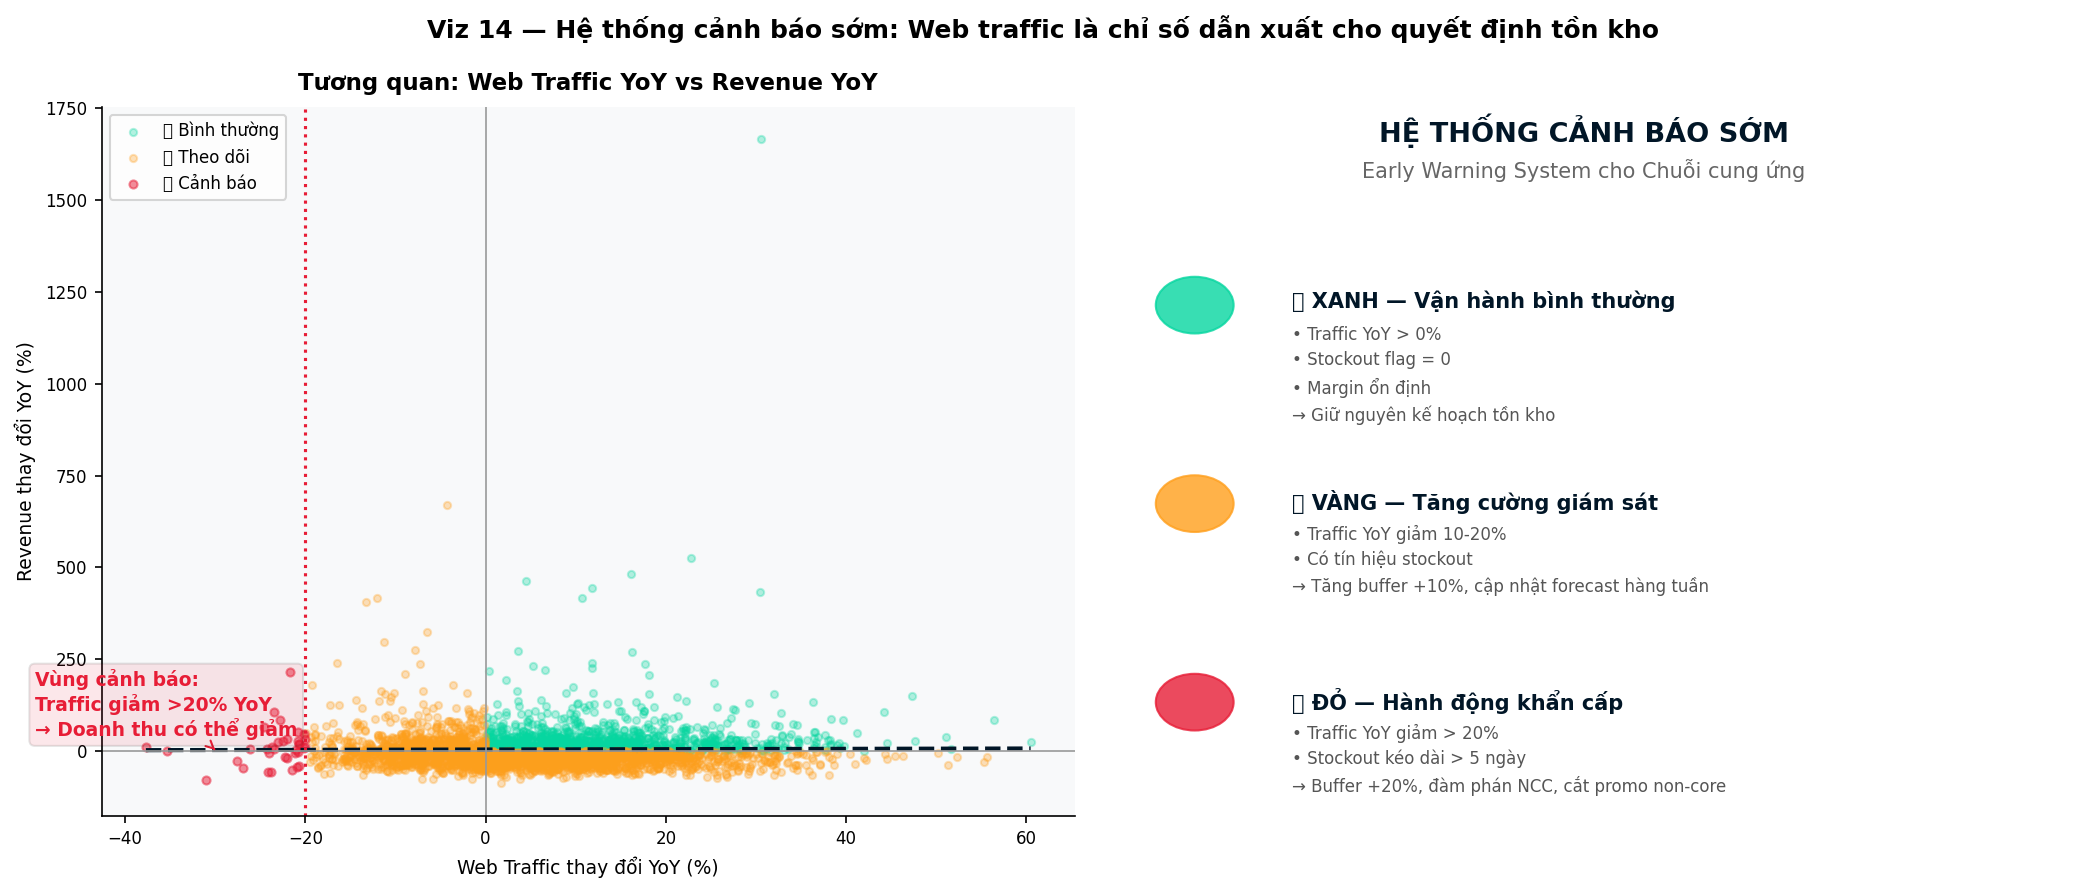

In [31]:
from src.analysis.prescriptive import viz14_early_warning_system
path = viz14_early_warning_system(df, os.path.join(CSV_DIR, "web_traffic.csv"),
                                   os.path.join(CSV_DIR, "inventory.csv"), OUT_DIR)
display(Image(filename=path))

---
# Kết luận

## Tóm tắt các phát hiện chính

| Cấp độ | Phát hiện | Giá trị kinh doanh |
|--------|-----------|-------------------|
| **Descriptive** | Doanh thu đạt đỉnh 2016 rồi suy giảm cấu trúc -44%; Mùa vụ chiếm 70% biến động | Mô hình cần nhận diện structural break |
| **Diagnostic** | Urban Blowout (giảm giá cứng 50K) gây margin âm T8; Promo chỉ hiệu quả 2 ngày rồi âm | Denoising + quản lý khuyến mãi |
| **Predictive** | Gridbreaker đạt R²=0.932 (in-sample), ~0.89 (out-of-sample), giảm MAE >40% | Dự báo 18 tháng tin cậy |
| **Prescriptive** | Buffer +15% giảm rủi ro stockout đáng kể | Tối ưu chi phí tồn kho |

## Kết nối dữ liệu đã sử dụng

6 bảng dữ liệu được kết nối:
- **sales ↔ inventory** → Stockout denoising
- **sales ↔ promotions** → Intervention analysis (Event Study)
- **sales ↔ web_traffic** → Leading indicator & Early Warning
- **products ↔ order_items ↔ orders** → Category analysis
- **Revenue ↔ COGS** → Cointegration & margin anomaly detection

## Đề xuất hành động

1. **Tồn kho:** Áp dụng buffer +15% (cuối tháng: +20%) → giảm rủi ro stockout đáng kể
2. **Marketing:** Ưu tiên Q1-Q2 (margin 17-18% + conversion cao nhất); Q3 chỉ duy trì tối thiểu
3. **Vận hành:** Triển khai hệ thống cảnh báo sớm kết hợp web traffic YoY + stockout flag + margin
4. **Kế hoạch:** Xây dựng annual plan làm cốt lõi (lag-365 là SHAP driver #1), dự phòng ~15% cho biến động ngắn hạn